## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np

pd.set_option('display.max_colwidth', 300)

## 2. Load Dataset

In [3]:
url = "https://storage.googleapis.com/msca-bdp-data-open/news_final_project/news_final_project.parquet"

df = pd.read_parquet(url, engine="pyarrow")

print("Dataset Shape:")
print(df.shape)

Dataset Shape:
(199989, 5)


## 3. Inspect Columns

In [4]:
print("Columns in Dataset:")
print(df.columns)

Columns in Dataset:
Index(['url', 'date', 'language', 'title', 'text'], dtype='object')


## 4. Data Types and Missing Values

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 199989 entries, 0 to 199988
Data columns (total 5 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   url       199989 non-null  object
 1   date      199989 non-null  object
 2   language  199989 non-null  object
 3   title     199989 non-null  object
 4   text      199989 non-null  object
dtypes: object(5)
memory usage: 7.6+ MB


## 5. Preview Dataset

In [6]:
df.head()

,url,date,language,title,text
0,https://blockworks.co/price/bad,2025-06-23,en,"Bad Idea AI Price (BAD), Market Cap, Price Today & Chart History - Blockworks","Bad Idea AI Price (BAD), Market Cap, Price Today & Chart History - BlockworksOpen menuBrandsnewsletterspodcastseventsroundtablestoken transparencyetf trackerpricesresearchanalyticshomepricesBad Idea AI price (BAD)Bad Idea AIBADLive Bad Idea AI price updates and the latest Bad Idea AI news.prices..."
1,https://boingboing.net/2024/07/01/this-ai-video-of-gymnastics-might-be-the-freakiest-ive-seen-yet.html,2024-07-01,en,This AI video of gymnastics might be the freakiest I've seen yet - Boing Boing,\n\nThis AI video of gymnastics might be the freakiest I've seen yet - Boing Boing\n\n \n\t\t\t\t\tMENU \n\n\t\t\t\t\t\tSEARCH \n\n\t\t\t\t\t\tSTORE \n\n\n\t\t\t\t\t\t\tMENU \n\t\t\t\t\t\t\tSEARCH ...
2,https://boingboing.net/2024/09/18/if-using-ai-feels-like-a-chore-try-this.html,2024-09-22,en,"If using AI feels like a chore, try this - Boing Boing","\n\nIf using AI feels like a chore, try this - Boing Boing\n \n\t\t\t\t\tMENU \n\n\t\t\t\t\t\tSEARCH \n\n\t\t\t\t\t\tSTORE \n\n\n\t\t\t\t\t\t\tMENU \n\t\t\t\t\t\t\tSEARCH \n\t\t\t\t\t\t\tSTORE ..."
3,https://citylife.capetown/gl/uncategorized/the-road-ahead-how-chinas-ai-foundation-model-is-shaping-the-future-of-autonomous-driving-technology/427293/,2023-11-10,en,The Road Ahead: How China's AI Foundation Model is Shaping the Future of Autonomous Driving Technology,The Road Ahead: How China's AI Foundation Model is Shaping the Future of Autonomous Driving Technology \n \n\nIr ao contidoVen. 10 de novembro de 2023 Vida da cidadePresentando as novas tecnoloxías e o poder da IA\n \n\nAInoticiaEspazotecnoloxíaSatélitecienciaEUAcontacto\n\n...
4,https://citylife.capetown/kk/uncategorized/microsoft-and-nvidia-are-making-it-easier-to-run-ai-models-on-windows/451379/,2023-11-19,en,Microsoft and Nvidia to Empower Developers with Windows AI Studio,"Microsoft and Nvidia to Empower Developers with Windows AI Studio \n \n\nмазмұнға өтуСенбі. 18 қараша, 2023 жыл Қала өміріЖаңа технологиялар мен AI күшін ашу\n \n\nAIжаңалықтарғарыштехнологиясерікғылымАҚШбайланыс\n\n \nжаңалықтар\n \nMicrosoft and Nvidia to Empower Develope..."


## 6. Random Article Samples

In [ ]:
for i, row in df.sample(3).iterrows():
    print("TITLE:")
    print(row['title'])
    print("\nTEXT:")
    print(row['text'][:1500])
    print("\nDATE:", row['date'])
    print("\n"+"="*80+"\n")

TITLE:
Chef portrait kitchen looking. AI | Premium Photo  - rawpixel

TEXT:
Chef portrait kitchen looking. AI | Premium Photo  - rawpixelrawpixelElementsDesignsDesign topicsElement topicsBoardshttps://www.rawpixel.com/services/licenseshttps://www.rawpixel.com/image/12007919Edit ImageSaveSaveEditCropCustom TextShare : Exclusive to rawpixel.comKeywords :facepersonclothingcoffee shopwomanrestaurantkitchenfoodChef portrait kitchen looking. AI generated Image by rawpixel.MoreAI GeneratedPremiumID : 12007919View personal and business license JPEGSmall JPEG 800 x 1200 px | 300 dpiLarge JPEG 2334 x 3500 px | 300 dpiBest Quality JPEG 2723 x 4084 px | 300 dpi©2023 Rawpixel Ltd.Chef portrait kitchen looking. AI generated Image by rawpixel.MoreWant to get in touch? We’d love to hear from you!contact@rawpixel.comjoin our Discord channel©2024 Rawpixel Ltd.User TermsPrivacy Cookie PolicyPricingAboutLicensesCreativity for GoodFAQJoin usimagine, create, remix

DATE: 2024-03-01


TITLE:
Latino casino, s

## 7. Missing Values Analysis

In [ ]:
missing = df.isnull().sum().sort_values(ascending=False)

missing

,0
url,0
date,0
language,0
title,0
text,0


## 8. Duplicate Articles

In [ ]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [ ]:
print("Duplicate titles:", df['title'].duplicated().sum())

Duplicate titles: 35684


In [ ]:
print("Duplicate titles:", df['text'].duplicated().sum())

Duplicate titles: 494


In [ ]:
duplicate_titles = df[df['title'].duplicated(keep=False)].sort_values(by='title')
duplicate_titles.head(4)

,url,date,language,title,text
172479,https://www.finnewsnetwork.com.au/archives/finance_news_network3392254.html,2025-12-09,en,\r \tBlackRock Touts AI as Key US Equities Driver | Finance News Network\r,"\n\r\n\tBlackRock Touts AI as Key US Equities Driver | Finance News Network\r\nNow Serving\nLatest News\nInterviews\nMarket Reports\nCompany Insights\n\n \nBlackRock Touts AI as Key US Equities Driver\nCompany News\n\nby Finance News Network\n December 09, 2025 02:38 PM\n\nBlackRock anticipates ..."
174900,https://www.finnewsnetwork.com.au/archives/finance_news_network3392254.html?utm_medium=rss,2025-12-09,en,\r \tBlackRock Touts AI as Key US Equities Driver | Finance News Network\r,"\n\r\n\tBlackRock Touts AI as Key US Equities Driver | Finance News Network\r\nNow Serving\nLatest News\nInterviews\nMarket Reports\nCompany Insights\n\n \nBlackRock Touts AI as Key US Equities Driver\nCompany News\n\nby Finance News Network\n December 09, 2025 02:38 PM\n\nBlackRock anticipates ..."
188936,https://www.finnewsnetwork.com.au/archives/finance_news_network2512250.html?utm_medium=rss,2025-08-25,en,\r \tDatabricks Acquires Tecton to Boost AI Deployment | Finance News Network\r,"\n\r\n\tDatabricks Acquires Tecton to Boost AI Deployment | Finance News Network\r\nNow Serving\nLatest News\nInterviews\nMarket Reports\nCompany Insights\n\n \nDatabricks Acquires Tecton to Boost AI Deployment\nCompany News\n\nby Finance News Network\n August 25, 2025 01:38 PM\n\nDatabricks has..."
74631,https://www.finnewsnetwork.com.au/archives/finance_news_network2512250.html,2025-08-25,en,\r \tDatabricks Acquires Tecton to Boost AI Deployment | Finance News Network\r,"\n\r\n\tDatabricks Acquires Tecton to Boost AI Deployment | Finance News Network\r\nNow Serving\nLatest News\nInterviews\nMarket Reports\nCompany Insights\n\n \nDatabricks Acquires Tecton to Boost AI Deployment\nCompany News\n\nby Finance News Network\n August 25, 2025 01:38 PM\n\nDatabricks has..."


## 9. Similarity Analysis of Articles Sharing Same Title


In [ ]:
get_ipython().system('pip install tqdm')

In [ ]:
title_counts = df['title'].value_counts()
duplicate_titles = title_counts[title_counts > 1].index.tolist()
df_duplicate_titles = df[df['title'].isin(duplicate_titles)].reset_index(drop=True)

print(f"Original DataFrame shape: {df.shape}")
print(f"DataFrame with duplicate titles shape: {df_duplicate_titles.shape}")


Original DataFrame shape: (199989, 5)
DataFrame with duplicate titles shape: (43797, 5)


In [ ]:
print("\nExamples of articles with duplicate titles (first 5 rows):")
df_duplicate_titles.head()


Examples of articles with duplicate titles (first 5 rows):


,url,date,language,title,text
0,https://citylife.capetown/gl/uncategorized/the-road-ahead-how-chinas-ai-foundation-model-is-shaping-the-future-of-autonomous-driving-technology/427293/,2023-11-10,en,The Road Ahead: How China's AI Foundation Model is Shaping the Future of Autonomous Driving Technology,The Road Ahead: How China's AI Foundation Model is Shaping the Future of Autonomous Driving Technology \n \n\nIr ao contidoVen. 10 de novembro de 2023 Vida da cidadePresentando as novas tecnoloxías e o poder da IA\n \n\nAInoticiaEspazotecnoloxíaSatélitecienciaEUAcontacto\n\n...
1,https://citylife.capetown/kk/uncategorized/microsoft-and-nvidia-are-making-it-easier-to-run-ai-models-on-windows/451379/,2023-11-19,en,Microsoft and Nvidia to Empower Developers with Windows AI Studio,"Microsoft and Nvidia to Empower Developers with Windows AI Studio \n \n\nмазмұнға өтуСенбі. 18 қараша, 2023 жыл Қала өміріЖаңа технологиялар мен AI күшін ашу\n \n\nAIжаңалықтарғарыштехнологиясерікғылымАҚШбайланыс\n\n \nжаңалықтар\n \nMicrosoft and Nvidia to Empower Develope..."
2,https://citylife.capetown/lb/uncategorized/how-googles-gemini-powered-bard-compares-with-openais-gpt-4/518309/,2023-12-12,en,Google Releases New Chatbot Bard as a Strong Competitor to OpenAI's ChatGPT,Google Releases New Chatbot Bard as a Strong Competitor to OpenAI's ChatGPT \n \n\nWiessel un InhaltDi. 12 Dezember 2023 Stad LiewenEntdeckt nei Technologien an d'Kraaft vun AI\n \n\nAINeiegkeetenSpaceTechnologySatelliteScienceUSKontakt\n\n \nAI\n\nNeiegkeeten\n \nGoogle verë...
3,https://www.14news.com/prnewswire/2022/07/15/virtus-artificial-intelligence-amp-technology-opportunities-fund-discloses-sources-distribution-section-19a-notice/,2022-07-15,en,Virtus Artificial Intelligence &amp; Technology Opportunities Fund Discloses Sources of Distribution - Section 19(a) Notice,Virtus Artificial Intelligence &amp; Technology Opportunities Fund Discloses Sources of Distribution - Section 19(a) Notice\n\nSkip to contentBirthday ClubAsk the ExpertPenguin CamCream of the Crop14 Job LinkBusiness FAQNewsCoronavirusDeadly Storms 2021WeatherSportsCalendarAbout UsTVRiver City W...
4,https://www.14news.com/prnewswire/2023/01/10/glia-completes-10th-year-growth-fueled-by-strong-adoption-its-digital-customer-service-platform-ai-automation-solutions/,2023-01-10,en,Glia Completes 10th Year of Growth Fueled by Strong Adoption of its Digital Customer Service Platform and AI Automation Solutions,Glia Completes 10th Year of Growth Fueled by Strong Adoption of its Digital Customer Service Platform and AI Automation Solutions\n\nSkip to contentPolar PlungeBirthday ClubAsk the ExpertPenguin CamCream of the Crop14 Job LinkBusiness FAQNewsElection ResultsElectionsCoronavirusDec. 10 TornadoWea...


In [ ]:
title_counts_duplicate = df_duplicate_titles['title'].value_counts()

title_counts_duplicate

,count
title,
Virtus Artificial Intelligence &amp; Technology Opportunities Fund Discloses Sources of Distribution - Section 19(a) Notice,65
Virtus AllianzGI Artificial Intelligence &amp; Technology Opportunities Fund Discloses Sources of Distribution - Section 19(a) Notice,42
Trump arrested? Putin jailed? Fake AI images spread online,34
Data Engineer - IT-Online,33
"Amazon, Google, Meta, Microsoft and other tech firms agree to AI safeguards set by the White House",30
...,...
Google says its AI designs chips better than humans – experts disagree | New Scientist,2
Crypto Presale Update: Lyno AI Nears Major Soft Cap as Investor FOMO Builds | MEXC News,2
Data Scientist at Parvana Recruitment - IT-Online,2


In [ ]:
df[df["title"] == "Virtus Artificial Intelligence &amp; Technology Opportunities Fund Discloses Sources of Distribution - Section 19(a) Notice"]

,url,date,language,title,text
49,https://www.14news.com/prnewswire/2022/07/15/virtus-artificial-intelligence-amp-technology-opportunities-fund-discloses-sources-distribution-section-19a-notice/,2022-07-15,en,Virtus Artificial Intelligence &amp; Technology Opportunities Fund Discloses Sources of Distribution - Section 19(a) Notice,Virtus Artificial Intelligence &amp; Technology Opportunities Fund Discloses Sources of Distribution - Section 19(a) Notice\n\nSkip to contentBirthday ClubAsk the ExpertPenguin CamCream of the Crop14 Job LinkBusiness FAQNewsCoronavirusDeadly Storms 2021WeatherSportsCalendarAbout UsTVRiver City W...
5978,https://www.wtap.com/prnewswire/2022/12/19/virtus-artificial-intelligence-amp-technology-opportunities-fund-discloses-sources-distribution-section-19a-notice/,2022-12-19,en,Virtus Artificial Intelligence &amp; Technology Opportunities Fund Discloses Sources of Distribution - Section 19(a) Notice,Virtus Artificial Intelligence &amp; Technology Opportunities Fund Discloses Sources of Distribution - Section 19(a) Notice\n\nSkip to contentHomeElection ResultsLatest VideoNewsWeatherSportsObituariesLivestreamHomeNewsApBusinessCommunityCOVID-19 UpdatesCrimeEconomyEducationElection ResultsPolit...
11027,https://www.wafb.com/prnewswire/2022/08/18/virtus-artificial-intelligence-amp-technology-opportunities-fund-discloses-sources-distribution-section-19a-notice/,2022-08-18,en,Virtus Artificial Intelligence &amp; Technology Opportunities Fund Discloses Sources of Distribution - Section 19(a) Notice,Virtus Artificial Intelligence &amp; Technology Opportunities Fund Discloses Sources of Distribution - Section 19(a) Notice\n\nSkip to contentFacebookInstagramTwitterLinkedInNewsLiveVideoWAFB+WeatherHurricane CenterSportsInvestigatorsLa. WeekendWAFB Channel 9NewsCrime9News NowTrafficYour MoneyVi...
14705,https://www.wbay.com/prnewswire/2022/07/15/virtus-artificial-intelligence-amp-technology-opportunities-fund-discloses-sources-distribution-section-19a-notice/,2022-07-15,en,Virtus Artificial Intelligence &amp; Technology Opportunities Fund Discloses Sources of Distribution - Section 19(a) Notice,Virtus Artificial Intelligence &amp; Technology Opportunities Fund Discloses Sources of Distribution - Section 19(a) Notice\n\nSkip to contentNewsWeatherSportsHealthSmall TownsCOVID-192 Your HealthLive NewscastsHomepageNewsCommunityCrimeHealthDr. RaiHigh SchoolInternationalNationalPoliticsSmall ...
15120,https://www.wjhg.com/prnewswire/2022/07/15/virtus-artificial-intelligence-amp-technology-opportunities-fund-discloses-sources-distribution-section-19a-notice/,2022-07-15,en,Virtus Artificial Intelligence &amp; Technology Opportunities Fund Discloses Sources of Distribution - Section 19(a) Notice,Virtus Artificial Intelligence &amp; Technology Opportunities Fund Discloses Sources of Distribution - Section 19(a) Notice\n\nSkip to contentNewsWeatherSportsWatch LiveShop LocalCOVID-19 MapHomepageNewsCrimeInternationalNationalPoliticsStateWatch LiveWeatherLive Doppler RadarMap RoomWildfire Fo...
...,...,...,...,...,...
190778,https://www.kcrg.com/prnewswire/2022/10/17/virtus-artificial-intelligence-amp-technology-opportunities-fund-discloses-sources-distribution-section-19a-notice/,2022-10-17,en,Virtus Artificial Intelligence &amp; Technology Opportunities Fund Discloses Sources of Distribution - Section 19(a) Notice,Virtus Artificial Intelligence &amp; Technology Opportunities Fund Discloses Sources of Distribution - Section 19(a) Notice\n\nSkip to contentShow You CareShop LocalStudent of the MonthEveryday FamiliesWorking IowaVisit IcelandVideoNewsWeatherSportsKCRG 9.2Watch LiveConnectYouNewsHomeNewsIowaNat...
195217,https://www.ksla.com/prnewswire/2022/12/19/virtus-artificial-intelligence-amp-technology-opportunities-fund-discloses-sources-distribution-section-19a-notice/,2022-12-19,en,Virtus Artificial Intelligence &amp; Technology Opportunities Fund Discloses Sources of Distribution - Section 19(a) Notice,Virtus Artificial Intelli

In [ ]:
from rapidfuzz import fuzz

def calculate_text_similarity(text1, text2):
    """
    Calculates the similarity between two text strings using rapidfuzz.fuzz.ratio.
    Returns a float between 0.0 and 100.0, which we'll convert to 0.0-1.0 range.
    """
    return fuzz.ratio(text1, text2) / 100.0

print("Function 'calculate_text_similarity' updated to use rapidfuzz successfully.")

Function 'calculate_text_similarity' updated to use rapidfuzz successfully.


In [ ]:
import numpy as np
from tqdm.notebook import tqdm

article_aggregated_similarity_data = []

grouped_by_title = df_duplicate_titles.groupby('title')

print("Calculating aggregated similarity for each article within duplicate title groups...")
for title, group in tqdm(grouped_by_title, desc="Processing title groups for aggregation"):
    texts_in_group = group['text'].tolist()
    indices_in_group = group.index.tolist() # Original indices in df_duplicate_titles

    # Iterate through each article in the group to calculate its aggregated similarity
    for i, current_idx in enumerate(indices_in_group):
        current_text = texts_in_group[i]

        # Collect similarities of current_text to all *other* texts in the group
        individual_similarities = []
        for j, other_idx in enumerate(indices_in_group):
            if i != j: # Don't compare an article to itself
                other_text = texts_in_group[j]
                score = calculate_text_similarity(current_text, other_text)
                individual_similarities.append(score)

        if individual_similarities: # Ensure there were other articles to compare against
            mean_similarity = np.mean(individual_similarities)
            max_similarity = np.max(individual_similarities)

            article_aggregated_similarity_data.append({
                'title': title,
                'original_df_index': current_idx, # Store original index for traceability
                'mean_group_similarity': mean_similarity,
                'max_group_similarity': max_similarity
            })

# Convert to DataFrame
article_similarity_summary_df = pd.DataFrame(article_aggregated_similarity_data)

print("\nAggregated Similarity per Article (first 5 rows):")
print(article_similarity_summary_df.head())

print("\nDescriptive statistics for mean group similarity:")
print(article_similarity_summary_df['mean_group_similarity'].describe())

print("\nDescriptive statistics for max group similarity:")
print(article_similarity_summary_df['max_group_similarity'].describe())

Calculating aggregated similarity for each article within duplicate title groups...


Processing title groups for aggregation:   0%|          | 0/8113 [00:00<?, ?it/s]


Aggregated Similarity per Article (first 5 rows):
                                                                                                       title  \
0                                \r \tBlackRock Touts AI as Key US Equities Driver | Finance News Network\r    
1                                \r \tBlackRock Touts AI as Key US Equities Driver | Finance News Network\r    
2                           \r \tDatabricks Acquires Tecton to Boost AI Deployment | Finance News Network\r    
3                           \r \tDatabricks Acquires Tecton to Boost AI Deployment | Finance News Network\r    
4  \r \tEnterprise AI Takes Center Stage as Over 50% of AI Use Cases Now Deliver Impact: Infosys Research\r    

   original_df_index  mean_group_similarity  max_group_similarity  
0              37662               0.997709              0.997709  
1              38200               0.997709              0.997709  
2              16152               1.000000              1.000000  
3   

In [ ]:
print("Descriptive Statistics for Similarity Scores:")
print(article_similarity_summary_df['mean_group_similarity'].describe())

Descriptive Statistics for Similarity Scores:
count    43797.000000
mean         0.836465
std          0.125597
min          0.017400
25%          0.817210
50%          0.873782
75%          0.906328
max          1.000000
Name: mean_group_similarity, dtype: float64


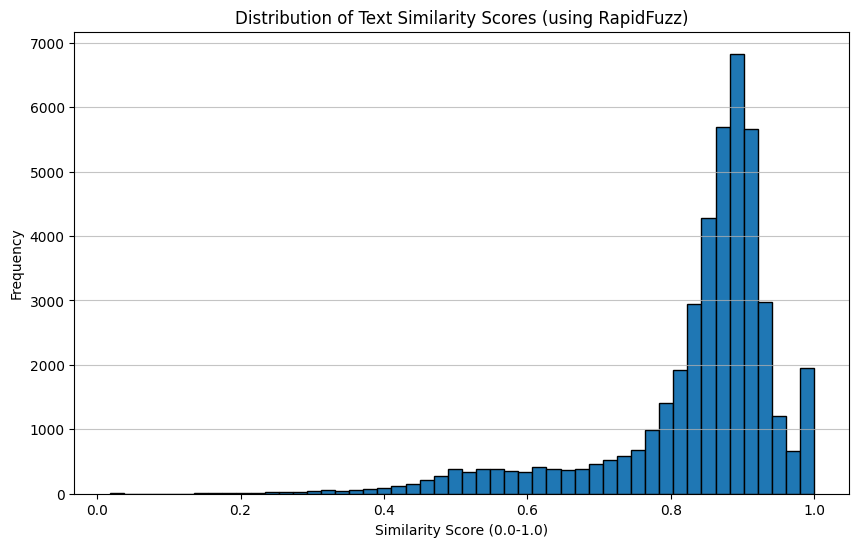

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(article_similarity_summary_df['mean_group_similarity'], bins=50, edgecolor='black')
plt.xlabel('Similarity Score (0.0-1.0)')
plt.ylabel('Frequency')
plt.title('Distribution of Text Similarity Scores (using RapidFuzz)')
plt.grid(axis='y', alpha=0.75)
plt.show()


## Title Length

In [7]:
# Calculate word count for each title
df['title_word_count'] = df['title'].apply(lambda x: len(str(x).split()))

print("Title Word Count Analysis:")
print("\nDescriptive Statistics:")
print(df['title_word_count'].describe())

# Define bins for word counts
# These bins can be adjusted based on the distribution seen in descriptive statistics
bins = [0, 5, 10, 15, 20, 25, 30, 35, 40, 50, df['title_word_count'].max() + 1]
labels = ['0-5', '6-10', '11-15', '16-20', '21-25', '26-30', '31-35', '36-40', '41-50', '50+']

# Create a new column with the word count bins
df['title_word_count_bin'] = pd.cut(df['title_word_count'], bins=bins, labels=labels, right=False)

print("\nDistribution of Title Word Counts (by bin):")
print(df['title_word_count_bin'].value_counts().sort_index())

Title Word Count Analysis:

Descriptive Statistics:
count    199989.000000
mean         13.871963
std           5.911542
min           1.000000
25%          11.000000
50%          13.000000
75%          16.000000
max        1325.000000
Name: title_word_count, dtype: float64

Distribution of Title Word Counts (by bin):
title_word_count_bin
0-5        519
6-10     26915
11-15    95818
16-20    56613
21-25    15083
26-30     3459
31-35     1067
36-40      343
41-50      114
50+         58
Name: count, dtype: int64


## 10. Article Length Analysis

In [ ]:
df['char_count'] = df['text'].str.len()
df['word_count'] = df['text'].str.split().str.len()

df[['char_count','word_count']].describe()

,char_count,word_count
count,199989.000000,199989.000000
mean,9098.766462,1231.988419
std,7264.733714,963.096173
min,21.000000,4.000000
25%,5245.000000,704.000000
50%,7622.000000,1034.000000
75%,11390.000000,1548.000000
max,580772.000000,39964.000000



--- Word Count Histogram ---


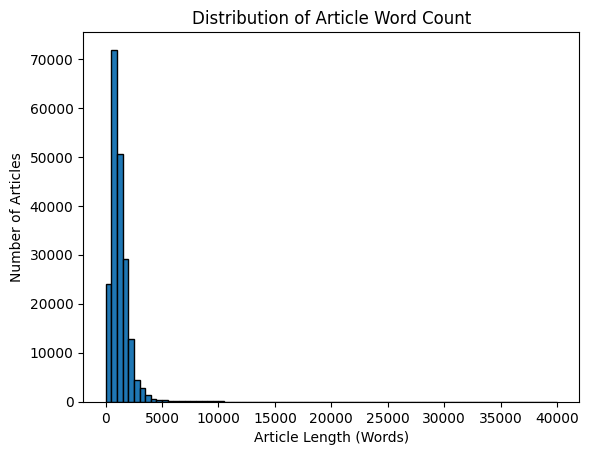


Detailed Word Count Bins:
Bin 1: 4 to 504 words, Count: 23958
Bin 2: 504 to 1003 words, Count: 71865
Bin 3: 1003 to 1502 words, Count: 50667
Bin 4: 1502 to 2002 words, Count: 29228
Bin 5: 2002 to 2502 words, Count: 12792
Bin 6: 2502 to 3001 words, Count: 4492
Bin 7: 3001 to 3500 words, Count: 2891
Bin 8: 3500 to 4000 words, Count: 1326
Bin 9: 4000 to 4500 words, Count: 652
Bin 10: 4500 to 4999 words, Count: 423
Bin 11: 4999 to 5498 words, Count: 269
Bin 12: 5498 to 5998 words, Count: 183
Bin 13: 5998 to 6498 words, Count: 203
Bin 14: 6498 to 6997 words, Count: 155
Bin 15: 6997 to 7496 words, Count: 218
Bin 16: 7496 to 7996 words, Count: 105
Bin 17: 7996 to 8496 words, Count: 97
Bin 18: 8496 to 8995 words, Count: 103
Bin 19: 8995 to 9494 words, Count: 88
Bin 20: 9494 to 9994 words, Count: 49
Bin 21: 9994 to 10494 words, Count: 55
Bin 22: 10494 to 10993 words, Count: 41
Bin 23: 10993 to 11492 words, Count: 16
Bin 24: 11492 to 11992 words, Count: 6
Bin 25: 11992 to 12492 words, Count: 5


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Word Count Histogram
print("\n--- Word Count Histogram ---")
counts_word, bins_word, _ = plt.hist(df['word_count'], bins=80, edgecolor='black')
plt.xlabel("Article Length (Words)")
plt.ylabel("Number of Articles")
plt.title("Distribution of Article Word Count")
plt.show()

print("\nDetailed Word Count Bins:")
for i in range(len(bins_word) - 1):
    print(f"Bin {i+1}: {bins_word[i]:.0f} to {bins_word[i+1]:.0f} words, Count: {int(counts_word[i])}")

#### Article with extremely high word count are mostly press release

In [ ]:
extremely_long_articles = df[df['word_count'] > 15000]

if not extremely_long_articles.empty:
    print(f"Found {len(extremely_long_articles)} articles with more than 15,000 words:")
    display(extremely_long_articles)
else:
    print("No articles found with more than 15,000 words.")

Found 62 articles with more than 15,000 words:


,url,date,language,title,text,char_count,word_count
1135,https://express-press-release.net/news/2024/02/01/1537771,2024-02-02,en,"Artificial Intelligence (AI) in Food & Beverages Market Size Volume, Share, Demand growth, Business Opportunity by 2032 – Express Press Release Distribution","\n\nArtificial Intelligence (AI) in Food & Beverages Market Size Volume, Share, Demand growth, Business Opportunity by 2032 – Express Press Release Distribution\n\nHome\nNews Releases\nSubmit Press Release\nAbout\n\nAbout Us\nHelp\nContacts\nEPR Nationwide\nDisclaimer\nPrivacy Policy\nTerms of S...",110276,15885
1136,https://express-press-release.net/news/2024/09/10/1626265,2024-09-10,en,Sports Analytics Market – Impact Of AI And Machine Learning – Express Press Release Distribution,\n\nSports Analytics Market – Impact Of AI And Machine Learning – Express Press Release Distribution\n\nHome\nNews Releases\nSubmit Press Release\nAbout\n\nAbout Us\nHelp\nContacts\nEPR Nationwide\nDisclaimer\nPrivacy Policy\nTerms of Service\n\n\nReports\nMarkets\n\nAccounting\nAdvertising\nAer...,116431,16931
1363,https://express-press-release.net/news/2024/04/15/1580367,2024-04-16,en,Text-to-Video AI Market Envisions a Whopping USD 1.6 Billion by 2030 Riding a Remarkable 36.03% CAGR Surge – Express Press Release Distribution,\n\nText-to-Video AI Market Envisions a Whopping USD 1.6 Billion by 2030 Riding a Remarkable 36.03% CAGR Surge – Express Press Release Distribution\n\nHome\nNews Releases\nSubmit Press Release\nAbout\n\nAbout Us\nHelp\nContacts\nEPR Nationwide\nDisclaimer\nPrivacy Policy\nTerms of Service\n\n\nR...,108881,15737
2812,https://www.dwarkesh.com/p/holden-karnofsky,2025-08-28,en,Holden Karnofsky - Transformative AI & Most Important Century,\nHolden Karnofsky - Transformative AI & Most Important Century\nDwarkesh PodcastSubscribeSign inShare this postCopy linkFacebookEmailNotesMoreDwarkesh PodcastHolden Karnofsky — History's most important century6Share this postCopy linkFacebookEmailNotesMore31×0:00Current time: 0:00 / Total time:...,135060,24454
3385,https://express-press-release.net/news/2024/01/14/1526084,2024-01-15,en,"Artificial Intelligence (AI) in Computer Vision Market Global Trends, Market Share, Industry Size, Growth, Opportunities and Forecast to 2032 – Express Press Release Distribution","\n\nArtificial Intelligence (AI) in Computer Vision Market Global Trends, Market Share, Industry Size, Growth, Opportunities and Forecast to 2032 – Express Press Release Distribution\n\nHome\nNews Releases\nSubmit Press Release\nAbout\n\nAbout Us\nHelp\nContacts\nEPR Nationwide\nDisclaimer\nPriv...",109583,15766
...,...,...,...,...,...,...,...
146982,https://express-press-release.net/news/2024/02/08/1542362,2024-02-09,en,"Causal AI Market Insights 2024: Top Impacting Factors, Growth Analysis and Industry Predictions And Outlook – Express Press Release Distribution","\n\nCausal AI Market Insights 2024: Top Impacting Factors, Growth Analysis and Industry Predictions And Outlook – Express Press Release Distribution\n\nHome\nNews Releases\nSubmit Press Release\nAbout\n\nAbout Us\nHelp\nContacts\nEPR Nationwide\nDisclaimer\nPrivacy Policy\nTerms of Service\n\n\n...",110597,15959
153204,https://express-press-release.net/news/2024/01/23/1532558,2024-01-24,en,"Artificial Intelligence in Manufacturing Market Size, Share, Competitive Landscape, Latest Innovations, Research, Segment, Progress, Growth Rate, and Global Forecast 2032 – Express Press Release Distribution","\n\nArtificial Intelligence in Manufacturing Market Size, Share, Competitive Landscape, Latest Innovations, Research, Segment, Progress, Growth Rate, and Global Forecast 2032 – Express Press Release Distribution\n\nHome\nNews Releases\nSubmit Press Release\nAbout\n\nAbout Us\nHelp\nContacts\nEPR...",110559,15889
155700,https://express-press-release.net/news/2024/07/10/1603547,2024-07-10,en,Wellness Resources by SunnyJ Announces Launch of AI Service to Enhance Client Connections – Express Press Rel

Total articles identified as 'Press Release': 272

Word Count Distribution for 'Press Release' Articles:
count      272.000000
mean      7016.408088
std       6152.113642
min        282.000000
25%       1025.750000
50%       8318.500000
75%      13986.000000
max      17392.000000
Name: word_count, dtype: float64


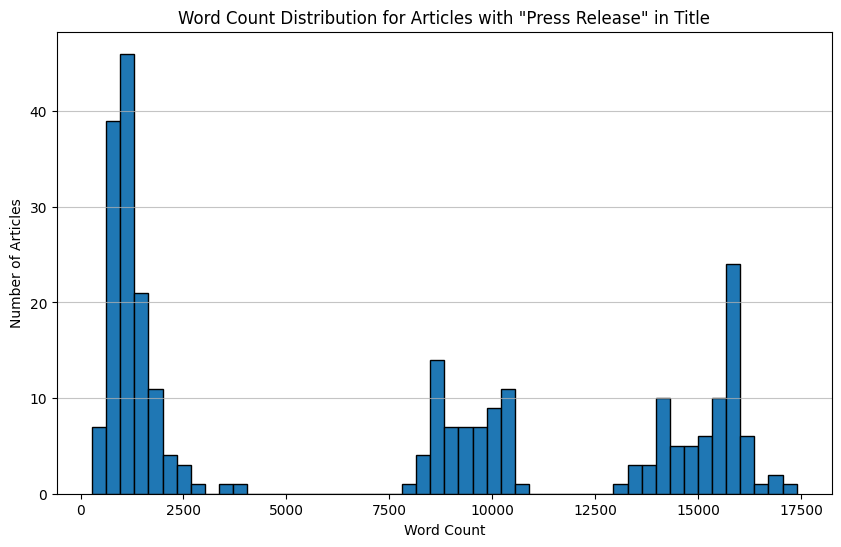

In [ ]:
press_release_articles = df[df['title'].str.contains('Press Release', case=False, na=False)]

print(f"Total articles identified as 'Press Release': {len(press_release_articles)}")

print("\nWord Count Distribution for 'Press Release' Articles:")
print(press_release_articles['word_count'].describe())

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(press_release_articles['word_count'], bins=50, edgecolor='black')
plt.xlabel('Word Count')
plt.ylabel('Number of Articles')
plt.title('Word Count Distribution for Articles with "Press Release" in Title')
plt.grid(axis='y', alpha=0.75)
plt.show()

#### Articles with extremely low word counts are mostly image/photo pages

In [ ]:
df[df['word_count'] < 100].sample(5)

,url,date,language,title,text,char_count,word_count
140517,https://www.rawpixel.com/image/12643735/architecture-furniture-building-plant-generated-image-rawpixel,2024-02-14,en,Architecture furniture building plant. AI | Free Photo - rawpixel,Architecture furniture building plant. AI | Free Photo - rawpixelrawpixelElementsDesignsDesign topicsElement topicsBoardshttps://www.rawpixel.com/services/licenseshttps://www.rawpixel.com/image/12643735Edit ImageSaveSaveEditCropCustom TextShare : Exclusive to rawpixel.comKeywords :house balcon...,933,97
101969,https://www.rawpixel.com/image/12090123/photo-image-background-face-person,2024-02-11,en,Child portrait smiling photo. AI | Free Photo - rawpixel,Child portrait smiling photo. AI | Free Photo - rawpixelrawpixelElementsDesignsDesign topicsElement topicsBoardshttps://www.rawpixel.com/services/licenseshttps://www.rawpixel.com/image/12090123Edit ImageSaveSaveEditCropCustom TextShare : Exclusive to rawpixel.comKeywords :facepersonclothingcowb...,869,94
194210,https://www.rawpixel.com/image/12198470/photo-image-face-flower-plant,2024-02-11,en,Photography curiosity standing holding. AI | Free Photo - rawpixel,Photography curiosity standing holding. AI | Free Photo - rawpixelrawpixelElementsDesignsDesign topicsElement topicsBoardshttps://www.rawpixel.com/services/licenseshttps://www.rawpixel.com/image/12198470Edit ImageSaveSaveEditCropCustom TextFlukeShare : Exclusive to rawpixel.comKeywords :person ...,962,99
46246,https://www.rawpixel.com/image/12438284/image-background-texture-face,2024-02-13,en,pharoah portrait art representation. AI | Free Photo Illustration - rawpixel,pharoah portrait art representation. AI | Free Photo Illustration - rawpixelrawpixelElementsDesignsDesign topicsElement topicsBoardshttps://www.rawpixel.com/services/licenseshttps://www.rawpixel.com/image/12438284Edit ImageSaveSaveEditCropCustom TextShare : Exclusive to rawpixel.comKeywords :pha...,942,98
105422,https://www.rawpixel.com/image/12211976/photo-image-background-plant-leaf,2024-02-12,en,Vegetable tomato fruit plant. AI | Free Photo - rawpixel,Vegetable tomato fruit plant. AI | Free Photo - rawpixelrawpixelElementsDesignsDesign topicsElement topicsBoardshttps://www.rawpixel.com/services/licenseshttps://www.rawpixel.com/image/12211976Edit ImageSaveSaveEditCropCustom Textchu_chutimaShare : Exclusive to rawpixel.comKeywords :agriculture...,910,95


#### Character Count Histogram


--- Character Count Histogram ---


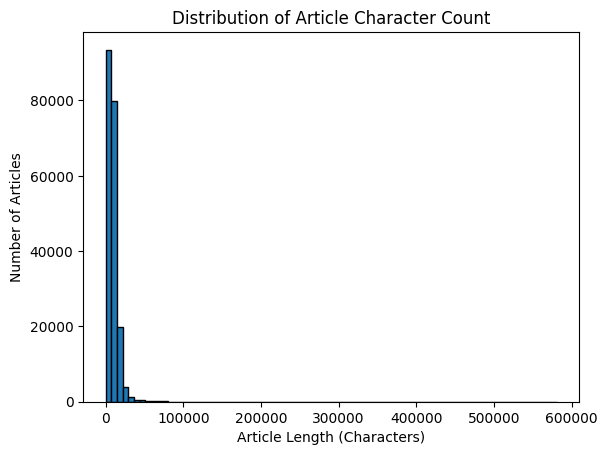


Detailed Character Count Bins:
Bin 1: 21 to 7280 characters, Count: 93483
Bin 2: 7280 to 14540 characters, Count: 79937
Bin 3: 14540 to 21799 characters, Count: 19853
Bin 4: 21799 to 29059 characters, Count: 3821
Bin 5: 29059 to 36318 characters, Count: 1220
Bin 6: 36318 to 43577 characters, Count: 532
Bin 7: 43577 to 50837 characters, Count: 447
Bin 8: 50837 to 58096 characters, Count: 209
Bin 9: 58096 to 65355 characters, Count: 165
Bin 10: 65355 to 72615 characters, Count: 120
Bin 11: 72615 to 79874 characters, Count: 63
Bin 12: 79874 to 87134 characters, Count: 25
Bin 13: 87134 to 94393 characters, Count: 23
Bin 14: 94393 to 101652 characters, Count: 24
Bin 15: 101652 to 108912 characters, Count: 22
Bin 16: 108912 to 116171 characters, Count: 29
Bin 17: 116171 to 123431 characters, Count: 3
Bin 18: 123431 to 130690 characters, Count: 0
Bin 19: 130690 to 137949 characters, Count: 2
Bin 20: 137949 to 145209 characters, Count: 1
Bin 21: 145209 to 152468 characters, Count: 1
Bin 22: 1

In [ ]:
# Character Count Histogram
print("\n--- Character Count Histogram ---")
counts_char, bins_char, _ = plt.hist(df['char_count'], bins=80, edgecolor='black')
plt.xlabel("Article Length (Characters)")
plt.ylabel("Number of Articles")
plt.title("Distribution of Article Character Count")
plt.show()

print("\nDetailed Character Count Bins:")
for i in range(len(bins_char) - 1):
    print(f"Bin {i+1}: {bins_char[i]:.0f} to {bins_char[i+1]:.0f} characters, Count: {int(counts_char[i])}")


In [ ]:
import nltk
import re
from nltk.corpus import stopwords
from nltk.util import ngrams

# Download NLTK data if not already downloaded
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('punkt_tab', quiet=True) # Explicitly download punkt_tab

# Define preprocess_text function
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', '', text)  # Remove punctuation and special characters
    tokens = nltk.word_tokenize(text)
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words]
    return ' '.join(tokens)

# Define generate_ngrams function
def generate_ngrams(text, n):
    tokens = nltk.word_tokenize(text)
    n_grams = list(ngrams(tokens, n))
    return [' '.join(gram) for gram in n_grams]

# Apply preprocessing to the 'title' column
df['cleaned_title'] = df['title'].apply(preprocess_text)

# Generate unigrams, bigrams, and trigrams
df['unigrams'] = df['cleaned_title'].apply(lambda x: generate_ngrams(x, 1))
df['bigrams'] = df['cleaned_title'].apply(lambda x: generate_ngrams(x, 2))
df['trigrams'] = df['cleaned_title'].apply(lambda x: generate_ngrams(x, 3))

print("nltk and re imported successfully, NLTK data downloaded, and N-grams generated.")
print(df[['title', 'cleaned_title', 'unigrams', 'bigrams', 'trigrams']].head())

nltk and re imported successfully, NLTK data downloaded, and N-grams generated.
                                                                                                    title  \
0                           Bad Idea AI Price (BAD), Market Cap, Price Today & Chart History - Blockworks   
1                          This AI video of gymnastics might be the freakiest I've seen yet - Boing Boing   
2                                                  If using AI feels like a chore, try this - Boing Boing   
3  The Road Ahead: How China's AI Foundation Model is Shaping the Future of Autonomous Driving Technology   
4                                       Microsoft and Nvidia to Empower Developers with Windows AI Studio   

                                                                        cleaned_title  \
0               bad idea ai price bad market cap price today chart history blockworks   
1                        ai video gymnastics might freakiest ive seen yet boing boing  

## 11. Frequency Analysis of N-grams

In [ ]:
all_unigrams = [item for sublist in df['unigrams'] for item in sublist]
all_bigrams = [item for sublist in df['bigrams'] for item in sublist]
all_trigrams = [item for sublist in df['trigrams'] for item in sublist]

print(f"Total unigrams generated: {len(all_unigrams)}")
print(f"Total bigrams generated: {len(all_bigrams)}")
print(f"Total trigrams generated: {len(all_trigrams)}")

Total unigrams generated: 2064044
Total bigrams generated: 1864055
Total trigrams generated: 1664270


In [ ]:
from collections import Counter

# Calculate frequency distribution for unigrams
unigram_counts = Counter(all_unigrams)

# Calculate frequency distribution for bigrams
bigram_counts = Counter(all_bigrams)

# Calculate frequency distribution for trigrams
trigram_counts = Counter(all_trigrams)

print("\nTop 50 Most Common Unigrams:")
for unigram, count in unigram_counts.most_common(50):
    print(f"{unigram}: {count}")

print("\nTop 50 Most Common Bigrams:")
for bigram, count in bigram_counts.most_common(50):
    print(f"{bigram}: {count}")

print("\nTop 50 Most Common Trigrams:")
for trigram, count in trigram_counts.most_common(50):
    print(f"{trigram}: {count}")


Top 50 Most Common Unigrams:
ai: 167237
news: 18365
new: 17234
intelligence: 16011
artificial: 15182
chatgpt: 14197
openai: 10656
data: 10292
google: 7766
photo: 7760
generative: 7590
launches: 7539
technology: 7475
rawpixel: 7316
times: 6686
tech: 6683
business: 6448
market: 5889
use: 5691
microsoft: 5627
using: 5122
says: 5033
us: 5028
free: 5019
global: 4863
platform: 4837
mexc: 4796
india: 4709
announces: 4576
first: 4439
learning: 4212
nvidia: 4107
machine: 3793
help: 3783
premium: 3782
unveils: 3767
price: 3717
ceo: 3531
future: 3506
world: 3497
could: 3480
report: 3409
company: 3182
research: 3168
digital: 3080
cloud: 3056
tools: 3013
stock: 2963
billion: 2958
model: 2925

Top 50 Most Common Bigrams:
artificial intelligence: 14770
generative ai: 7271
photo rawpixel: 5215
new ai: 3846
free photo: 3690
ai free: 3665
ai premium: 3547
premium photo: 3547
machine learning: 3373
using ai: 2626
use ai: 2443
photo illustration: 2022
illustration rawpixel: 2022
ai chatbot: 1922
mexc new

#### photo pages

In [ ]:
photo_rawpixel_cleaned_articles = df[df['cleaned_title'].str.contains('photo rawpixel', case=False, na=False)]

print(f"Found {len(photo_rawpixel_cleaned_articles)} articles with 'photo rawpixel' in their CLEANED title:")
display(photo_rawpixel_cleaned_articles)

Found 5215 articles with 'photo rawpixel' in their CLEANED title:


,url,date,language,title,text,char_count,word_count,cleaned_title,unigrams,bigrams,trigrams
157,https://www.rawpixel.com/image/12012573/photo-image-white-background-animal,2024-03-01,en,Zebra wildlife animal mammal. AI | Premium Photo - rawpixel,Zebra wildlife animal mammal. AI | Premium Photo - rawpixelrawpixelElementsDesignsDesign topicsElement topicsBoardshttps://www.rawpixel.com/services/licenseshttps://www.rawpixel.com/image/12012573Edit ImageSaveSaveEditCropCustom TextShare : Exclusive to rawpixel.comKeywords :animalnaturefamilyw...,879,95,zebra wildlife animal mammal ai premium photo rawpixel,"[zebra, wildlife, animal, mammal, ai, premium, photo, rawpixel]","[zebra wildlife, wildlife animal, animal mammal, mammal ai, ai premium, premium photo, photo rawpixel]","[zebra wildlife animal, wildlife animal mammal, animal mammal ai, mammal ai premium, ai premium photo, premium photo rawpixel]"
158,https://www.rawpixel.com/image/12015349/photo-image-background-green-eye,2024-03-01,en,Gecko wildlife portrait reptile. AI | Premium Photo - rawpixel,Gecko wildlife portrait reptile. AI | Premium Photo - rawpixelrawpixelElementsDesignsDesign topicsElement topicsBoardshttps://www.rawpixel.com/services/licenseshttps://www.rawpixel.com/image/12015349Edit ImageSaveSaveEditCropCustom TextTechiShare : Exclusive to rawpixel.comKeywords :eyeanimalna...,879,93,gecko wildlife portrait reptile ai premium photo rawpixel,"[gecko, wildlife, portrait, reptile, ai, premium, photo, rawpixel]","[gecko wildlife, wildlife portrait, portrait reptile, reptile ai, ai premium, premium photo, photo rawpixel]","[gecko wildlife portrait, wildlife portrait reptile, portrait reptile ai, reptile ai premium, ai premium photo, premium photo rawpixel]"
162,https://www.rawpixel.com/image/12201244/photo-image-person-men-fashion,2024-02-12,en,Portrait outdoors t-shirt tattoo. AI | Free Photo - rawpixel,Portrait outdoors t-shirt tattoo. AI | Free Photo - rawpixelrawpixelElementsDesignsDesign topicsElement topicsBoardshttps://www.rawpixel.com/services/licenseshttps://www.rawpixel.com/image/12201244Edit ImageSaveSaveEditCropCustom Textdunno design labShare : Exclusive to rawpixel.comKeywords :pe...,901,95,portrait outdoors tshirt tattoo ai free photo rawpixel,"[portrait, outdoors, tshirt, tattoo, ai, free, photo, rawpixel]","[portrait outdoors, outdoors tshirt, tshirt tattoo, tattoo ai, ai free, free photo, photo rawpixel]","[portrait outdoors tshirt, outdoors tshirt tattoo, tshirt tattoo ai, tattoo ai free, ai free photo, free photo rawpixel]"
163,https://www.rawpixel.com/image/12202298/photo-image-face-plant-person,2024-02-12,en,Laughing wedding adult dress. AI | Free Photo - rawpixel,Laughing wedding adult dress. AI | Free Photo - rawpixelrawpixelElementsDesignsDesign topicsElement topicsBoardshttps://www.rawpixel.com/services/licenseshttps://www.rawpixel.com/image/12202298Edit ImageSaveSaveEditCropCustom TextShare : Exclusive to rawpixel.comKeywords :wedding photographymen...,905,97,laughing wedding adult dress ai free photo rawpixel,"[laughing, wedding, adult, dress, ai, free, photo, rawpixel]","[laughing wedding, wedding adult, adult dress, dress ai, ai free, free photo, photo rawpixel]","[laughing wedding adult, wedding adult dress, adult dress ai, dress ai free, ai free photo, free photo rawpixel]"
164,https://www.rawpixel.com/image/12203577/photo-image-texture-person-blue,2024-02-12,en,Dancing shorts determination athleticism. AI | Free Photo - rawpixel,Dancing shorts determination athleticism. AI | Free Photo - rawpixelrawpixelElementsDesignsDesign topicsElement topicsBoardshttps://www.rawpixel.com/services/licenseshttps://www.rawpixel.com/image/12203577Edit ImageSaveSaveEditCropCustom Textdunno design labShare : Exclusive to rawpixel.comKeyw...,948,99,dancing shorts determination athleticism ai free photo rawpixel,"[dancing, shorts, determination, athleticism, ai, free, photo, rawpixel]","[dancing shorts, shorts determination, determination athleticism, athleti

In [ ]:
ai_free_photo_cleaned_articles = df[df['cleaned_title'].str.contains('ai free photo', case=False, na=False)]

print(f"Found {len(ai_free_photo_cleaned_articles)} articles with 'ai free photo' in their CLEANED title:")
display(ai_free_photo_cleaned_articles)

Found 3626 articles with 'ai free photo' in their CLEANED title:


,url,date,language,title,text,char_count,word_count,cleaned_title,unigrams,bigrams,trigrams
162,https://www.rawpixel.com/image/12201244/photo-image-person-men-fashion,2024-02-12,en,Portrait outdoors t-shirt tattoo. AI | Free Photo - rawpixel,Portrait outdoors t-shirt tattoo. AI | Free Photo - rawpixelrawpixelElementsDesignsDesign topicsElement topicsBoardshttps://www.rawpixel.com/services/licenseshttps://www.rawpixel.com/image/12201244Edit ImageSaveSaveEditCropCustom Textdunno design labShare : Exclusive to rawpixel.comKeywords :pe...,901,95,portrait outdoors tshirt tattoo ai free photo rawpixel,"[portrait, outdoors, tshirt, tattoo, ai, free, photo, rawpixel]","[portrait outdoors, outdoors tshirt, tshirt tattoo, tattoo ai, ai free, free photo, photo rawpixel]","[portrait outdoors tshirt, outdoors tshirt tattoo, tshirt tattoo ai, tattoo ai free, ai free photo, free photo rawpixel]"
163,https://www.rawpixel.com/image/12202298/photo-image-face-plant-person,2024-02-12,en,Laughing wedding adult dress. AI | Free Photo - rawpixel,Laughing wedding adult dress. AI | Free Photo - rawpixelrawpixelElementsDesignsDesign topicsElement topicsBoardshttps://www.rawpixel.com/services/licenseshttps://www.rawpixel.com/image/12202298Edit ImageSaveSaveEditCropCustom TextShare : Exclusive to rawpixel.comKeywords :wedding photographymen...,905,97,laughing wedding adult dress ai free photo rawpixel,"[laughing, wedding, adult, dress, ai, free, photo, rawpixel]","[laughing wedding, wedding adult, adult dress, dress ai, ai free, free photo, photo rawpixel]","[laughing wedding adult, wedding adult dress, adult dress ai, dress ai free, ai free photo, free photo rawpixel]"
164,https://www.rawpixel.com/image/12203577/photo-image-texture-person-blue,2024-02-12,en,Dancing shorts determination athleticism. AI | Free Photo - rawpixel,Dancing shorts determination athleticism. AI | Free Photo - rawpixelrawpixelElementsDesignsDesign topicsElement topicsBoardshttps://www.rawpixel.com/services/licenseshttps://www.rawpixel.com/image/12203577Edit ImageSaveSaveEditCropCustom Textdunno design labShare : Exclusive to rawpixel.comKeyw...,948,99,dancing shorts determination athleticism ai free photo rawpixel,"[dancing, shorts, determination, athleticism, ai, free, photo, rawpixel]","[dancing shorts, shorts determination, determination athleticism, athleticism ai, ai free, free photo, photo rawpixel]","[dancing shorts determination, shorts determination athleticism, determination athleticism ai, athleticism ai free, ai free photo, free photo rawpixel]"
165,https://www.rawpixel.com/image/12208880/photo-image-aesthetic-person-women,2024-02-12,en,Sports adult white woman. AI | Free Photo - rawpixel,Sports adult white woman. AI | Free Photo - rawpixelrawpixelElementsDesignsDesign topicsElement topicsBoardshttps://www.rawpixel.com/services/licenseshttps://www.rawpixel.com/image/12208880Edit ImageSaveSaveEditCropCustom TextSasiShare : Exclusive to rawpixel.comKeywords :dance photographyadult...,900,98,sports adult white woman ai free photo rawpixel,"[sports, adult, white, woman, ai, free, photo, rawpixel]","[sports adult, adult white, white woman, woman ai, ai free, free photo, photo rawpixel]","[sports adult white, adult white woman, white woman ai, woman ai free, ai free photo, free photo rawpixel]"
168,https://www.rawpixel.com/image/12548880/wallpaper-pattern-flower-backgrounds-generated-image-rawpixel,2024-02-13,en,Wallpaper pattern flower backgrounds. AI | Free Photo Illustration - rawpixel,Wallpaper pattern flower backgrounds. AI | Free Photo Illustration - rawpixelrawpixelElementsDesignsDesign topicsElement topicsBoardshttps://www.rawpixel.com/services/licenseshttps://www.rawpixel.com/image/12548880Edit ImageSaveSaveEditCropCustom TextAewShare : Exclusive to rawpixel.comKeywords ...,981,103,wallpaper pattern flower backgrounds ai free photo illustration rawpixel,"[wallpaper, pattern, flower, backgrounds, ai, free, photo, illustration, rawpixel]","[wallpaper pattern, pattern

In [ ]:
premium_photo_cleaned_articles = df[df['cleaned_title'].str.contains('premium photo', case=False, na=False)]

print(f"Found {len(premium_photo_cleaned_articles)} articles with 'premium photo' in their CLEANED title:")
display(premium_photo_cleaned_articles)

Found 3547 articles with 'premium photo' in their CLEANED title:


,url,date,language,title,text,char_count,word_count,cleaned_title,unigrams,bigrams,trigrams
157,https://www.rawpixel.com/image/12012573/photo-image-white-background-animal,2024-03-01,en,Zebra wildlife animal mammal. AI | Premium Photo - rawpixel,Zebra wildlife animal mammal. AI | Premium Photo - rawpixelrawpixelElementsDesignsDesign topicsElement topicsBoardshttps://www.rawpixel.com/services/licenseshttps://www.rawpixel.com/image/12012573Edit ImageSaveSaveEditCropCustom TextShare : Exclusive to rawpixel.comKeywords :animalnaturefamilyw...,879,95,zebra wildlife animal mammal ai premium photo rawpixel,"[zebra, wildlife, animal, mammal, ai, premium, photo, rawpixel]","[zebra wildlife, wildlife animal, animal mammal, mammal ai, ai premium, premium photo, photo rawpixel]","[zebra wildlife animal, wildlife animal mammal, animal mammal ai, mammal ai premium, ai premium photo, premium photo rawpixel]"
158,https://www.rawpixel.com/image/12015349/photo-image-background-green-eye,2024-03-01,en,Gecko wildlife portrait reptile. AI | Premium Photo - rawpixel,Gecko wildlife portrait reptile. AI | Premium Photo - rawpixelrawpixelElementsDesignsDesign topicsElement topicsBoardshttps://www.rawpixel.com/services/licenseshttps://www.rawpixel.com/image/12015349Edit ImageSaveSaveEditCropCustom TextTechiShare : Exclusive to rawpixel.comKeywords :eyeanimalna...,879,93,gecko wildlife portrait reptile ai premium photo rawpixel,"[gecko, wildlife, portrait, reptile, ai, premium, photo, rawpixel]","[gecko wildlife, wildlife portrait, portrait reptile, reptile ai, ai premium, premium photo, photo rawpixel]","[gecko wildlife portrait, wildlife portrait reptile, portrait reptile ai, reptile ai premium, ai premium photo, premium photo rawpixel]"
159,https://www.rawpixel.com/image/12040675/image-aesthetic-plant-grass,2024-03-01,en,Landscape city architecture cityscape. AI | Premium Photo Illustration - rawpixel,Landscape city architecture cityscape. AI | Premium Photo Illustration - rawpixelrawpixelElementsDesignsDesign topicsElement topicsBoardshttps://www.rawpixel.com/services/licenseshttps://www.rawpixel.com/image/12040675Edit ImageSaveSaveEditCropCustom TextAewShare : Exclusive to rawpixel.comKeywo...,957,98,landscape city architecture cityscape ai premium photo illustration rawpixel,"[landscape, city, architecture, cityscape, ai, premium, photo, illustration, rawpixel]","[landscape city, city architecture, architecture cityscape, cityscape ai, ai premium, premium photo, photo illustration, illustration rawpixel]","[landscape city architecture, city architecture cityscape, architecture cityscape ai, cityscape ai premium, ai premium photo, premium photo illustration, photo illustration rawpixel]"
161,https://www.rawpixel.com/image/12177045/image-background-face-person,2024-03-02,en,Birthday cute baby toy. AI | Premium Photo Illustration - rawpixel,Birthday cute baby toy. AI | Premium Photo Illustration - rawpixelrawpixelElementsDesignsDesign topicsElement topicsBoardshttps://www.rawpixel.com/services/licenseshttps://www.rawpixel.com/image/12177045Edit ImageSaveSaveEditCropCustom TextShare : Exclusive to rawpixel.comKeywords :cartoonfacepe...,875,95,birthday cute baby toy ai premium photo illustration rawpixel,"[birthday, cute, baby, toy, ai, premium, photo, illustration, rawpixel]","[birthday cute, cute baby, baby toy, toy ai, ai premium, premium photo, photo illustration, illustration rawpixel]","[birthday cute baby, cute baby toy, baby toy ai, toy ai premium, ai premium photo, premium photo illustration, photo illustration rawpixel]"
166,https://www.rawpixel.com/image/12398617/photo-image-black-background-table-plate,2024-03-03,en,Noodle food chopsticks meal. AI | Premium Photo - rawpixel,Noodle food chopsticks meal. AI | Premium Photo - rawpixelrawpixelElementsDesignsDesign topicsElement topicsBoardshttps://www.rawpixel.com/services/licenseshttps://www.rawpixel.com/image/12398617Edit ImageSaveSaveEditCropCustom TextShare : Exclusive to rawpixel.comKeywor

In [ ]:
photo_illustration_cleaned_articles = df[df['cleaned_title'].str.contains('photo illustration', case=False, na=False)]

print(f"Found {len(photo_illustration_cleaned_articles)} articles with 'photo illustration' in their CLEANED title:")
display(photo_illustration_cleaned_articles)

Found 2022 articles with 'photo illustration' in their CLEANED title:


,url,date,language,title,text,char_count,word_count,cleaned_title,unigrams,bigrams,trigrams
159,https://www.rawpixel.com/image/12040675/image-aesthetic-plant-grass,2024-03-01,en,Landscape city architecture cityscape. AI | Premium Photo Illustration - rawpixel,Landscape city architecture cityscape. AI | Premium Photo Illustration - rawpixelrawpixelElementsDesignsDesign topicsElement topicsBoardshttps://www.rawpixel.com/services/licenseshttps://www.rawpixel.com/image/12040675Edit ImageSaveSaveEditCropCustom TextAewShare : Exclusive to rawpixel.comKeywo...,957,98,landscape city architecture cityscape ai premium photo illustration rawpixel,"[landscape, city, architecture, cityscape, ai, premium, photo, illustration, rawpixel]","[landscape city, city architecture, architecture cityscape, cityscape ai, ai premium, premium photo, photo illustration, illustration rawpixel]","[landscape city architecture, city architecture cityscape, architecture cityscape ai, cityscape ai premium, ai premium photo, premium photo illustration, photo illustration rawpixel]"
161,https://www.rawpixel.com/image/12177045/image-background-face-person,2024-03-02,en,Birthday cute baby toy. AI | Premium Photo Illustration - rawpixel,Birthday cute baby toy. AI | Premium Photo Illustration - rawpixelrawpixelElementsDesignsDesign topicsElement topicsBoardshttps://www.rawpixel.com/services/licenseshttps://www.rawpixel.com/image/12177045Edit ImageSaveSaveEditCropCustom TextShare : Exclusive to rawpixel.comKeywords :cartoonfacepe...,875,95,birthday cute baby toy ai premium photo illustration rawpixel,"[birthday, cute, baby, toy, ai, premium, photo, illustration, rawpixel]","[birthday cute, cute baby, baby toy, toy ai, ai premium, premium photo, photo illustration, illustration rawpixel]","[birthday cute baby, cute baby toy, baby toy ai, toy ai premium, ai premium photo, premium photo illustration, photo illustration rawpixel]"
168,https://www.rawpixel.com/image/12548880/wallpaper-pattern-flower-backgrounds-generated-image-rawpixel,2024-02-13,en,Wallpaper pattern flower backgrounds. AI | Free Photo Illustration - rawpixel,Wallpaper pattern flower backgrounds. AI | Free Photo Illustration - rawpixelrawpixelElementsDesignsDesign topicsElement topicsBoardshttps://www.rawpixel.com/services/licenseshttps://www.rawpixel.com/image/12548880Edit ImageSaveSaveEditCropCustom TextAewShare : Exclusive to rawpixel.comKeywords ...,981,103,wallpaper pattern flower backgrounds ai free photo illustration rawpixel,"[wallpaper, pattern, flower, backgrounds, ai, free, photo, illustration, rawpixel]","[wallpaper pattern, pattern flower, flower backgrounds, backgrounds ai, ai free, free photo, photo illustration, illustration rawpixel]","[wallpaper pattern flower, pattern flower backgrounds, flower backgrounds ai, backgrounds ai free, ai free photo, free photo illustration, photo illustration rawpixel]"
364,https://www.rawpixel.com/image/12189322/image-background-hamburger-illustration,2024-02-20,en,Cheese burger food hamburger. AI | Free Photo Illustration - rawpixel,Cheese burger food hamburger. AI | Free Photo Illustration - rawpixelrawpixelElementsDesignsDesign topicsElement topicsBoardshttps://www.rawpixel.com/services/licenseshttps://www.rawpixel.com/image/12189322Edit ImageSaveSaveEditCropCustom TextShare : Exclusive to rawpixel.comKeywords :hamburgert...,917,99,cheese burger food hamburger ai free photo illustration rawpixel,"[cheese, burger, food, hamburger, ai, free, photo, illustration, rawpixel]","[cheese burger, burger food, food hamburger, hamburger ai, ai free, free photo, photo illustration, illustration rawpixel]","[cheese burger food, burger food hamburger, food hamburger ai, hamburger ai free, ai free photo, free photo illustration, photo illustration rawpixel]"
365,https://www.rawpixel.com/image/12375320/image-wallpaper-background-aesthetic,2024-03-02,en,Towel brown chocolate furniture. AI | Premium Photo Illustration - rawpixel,Towel brown chocolate furniture. AI | Prem

In [ ]:
ai_art_photos_cleaned_articles = df[df['cleaned_title'].str.contains('ai art photos', case=False, na=False)]

print(f"Found {len(ai_art_photos_cleaned_articles)} articles with 'ai art photos' in their CLEANED title:")
display(ai_art_photos_cleaned_articles)

Found 548 articles with 'ai art photos' in their CLEANED title:


,url,date,language,title,text,char_count,word_count,cleaned_title,unigrams,bigrams,trigrams
907,http://www.nativestew.com/2023/10/back-home.html,2023-10-27,en,"Native Stew - Bahamas AI Art, Photos, Videos: Back Home","\nNative Stew - Bahamas AI Art, Photos, Videos: Back Home\nPages\nHome\n\n\nPeople\n\n\nPlaces\n\n\nThings\n\nTuesday, October 24, 2023\n\nBack Home\n ""Back Home"" - AI art©A. Derek Catalano \nat\n\nOctober 24, 2023\nEmail ThisBlogThis!Share to TwitterShare to FacebookShare to Pinterest\n\nLabels...",2314,313,native stew bahamas ai art photos videos back home,"[native, stew, bahamas, ai, art, photos, videos, back, home]","[native stew, stew bahamas, bahamas ai, ai art, art photos, photos videos, videos back, back home]","[native stew bahamas, stew bahamas ai, bahamas ai art, ai art photos, art photos videos, photos videos back, videos back home]"
1948,https://www.nativestew.com/2024/06/tropic-summer-murals.html,2024-06-13,en,"Native Stew - Bahamas AI Art, Photos, Videos: Tropic Summer Murals","\n\nNative Stew - Bahamas AI Art, Photos, Videos: Tropic Summer Murals\nPages\nHome\n\n\nPeople\n\n\nPlaces\n\n\nThings\n\nWednesday, June 12, 2024\n\nTropic Summer Murals\n ""Tropic Summer Mural"" - Bahamas AI art ©A. Derek Catalano""Tropic Summer Mural"" - Bahamas AI art ©A. Derek Catalano\nat\n...",3547,493,native stew bahamas ai art photos videos tropic summer murals,"[native, stew, bahamas, ai, art, photos, videos, tropic, summer, murals]","[native stew, stew bahamas, bahamas ai, ai art, art photos, photos videos, videos tropic, tropic summer, summer murals]","[native stew bahamas, stew bahamas ai, bahamas ai art, ai art photos, art photos videos, photos videos tropic, videos tropic summer, tropic summer murals]"
2044,http://www.nativestew.com/2024/09/seagull-dunes-pc-wallpaper.html,2024-09-06,en,"Native Stew - Bahamas AI Art, Photos, Videos: Seagull Dunes - PC Wallpaper","\nNative Stew - Bahamas AI Art, Photos, Videos: Seagull Dunes - PC Wallpaper\nPages\nHome\n\n\nPeople\n\n\nPlaces\n\n\nThings\n\nFriday, September 6, 2024\n\nSeagull Dunes - PC Wallpaper\n ""Seagull Dunes"" - Bahamas AI art©A. Derek CatalanoDownload full size wallpaper: 5376x3072\nat\n\nSeptember ...",4007,552,native stew bahamas ai art photos videos seagull dunes pc wallpaper,"[native, stew, bahamas, ai, art, photos, videos, seagull, dunes, pc, wallpaper]","[native stew, stew bahamas, bahamas ai, ai art, art photos, photos videos, videos seagull, seagull dunes, dunes pc, pc wallpaper]","[native stew bahamas, stew bahamas ai, bahamas ai art, ai art photos, art photos videos, photos videos seagull, videos seagull dunes, seagull dunes pc, dunes pc wallpaper]"
2193,https://www.nativestew.com/2024/05/beach-goddess.html,2024-05-21,en,"Native Stew - Bahamas AI Art, Photos, Videos: Sea Goddess","\nNative Stew - Bahamas AI Art, Photos, Videos: Sea Goddess\n\nPages\nHome\n\n\nPeople\n\n\nPlaces\n\n\nThings\n\nMonday, May 20, 2024\n\nSea Goddess\n ""Sea Goddess"" - Bahamas AI art©A. Derek Catalano ""Sea Goddess"" - Bahamas AI art©A. Derek Catalano\nat\n\nMay 20, 2024\nEmail ThisBlogThis!Share...",3444,481,native stew bahamas ai art photos videos sea goddess,"[native, stew, bahamas, ai, art, photos, videos, sea, goddess]","[native stew, stew bahamas, bahamas ai, ai art, art photos, photos videos, videos sea, sea goddess]","[native stew bahamas, stew bahamas ai, bahamas ai art, ai art photos, art photos videos, photos videos sea, videos sea goddess]"
2641,https://www.nativestew.com/2024/01/fly-high.html,2024-01-11,en,"Native Stew - Bahamas AI Art, Photos, Videos: Fly High","\nNative Stew - Bahamas AI Art, Photos, Videos: Fly High\nPages\nHome\n\n\nPeople\n\n\nPlaces\n\n\nThings\n\nWednesday, January 10, 2024\n\nFly High\n ""Fly High"" - Bahamas AI art©A. Derek Catalano ""Fly Higher"" - Bahamas AI art©A. Derek Catalano\nat\n\nJanuary 10, 2024\nEmail ThisBlogThis!Share...",2572,351,native stew bahamas ai art photos videos fly high,"[native, stew, bahamas, ai, art

In [ ]:
bahamas_ai_art_cleaned_articles = df[df['cleaned_title'].str.contains('bahamas ai art', case=False, na=False)]

print(f"Found {len(bahamas_ai_art_cleaned_articles)} articles with 'bahamas ai art' in their CLEANED title:")
display(bahamas_ai_art_cleaned_articles)

Found 546 articles with 'bahamas ai art' in their CLEANED title:


,url,date,language,title,text,char_count,word_count,cleaned_title,unigrams,bigrams,trigrams
907,http://www.nativestew.com/2023/10/back-home.html,2023-10-27,en,"Native Stew - Bahamas AI Art, Photos, Videos: Back Home","\nNative Stew - Bahamas AI Art, Photos, Videos: Back Home\nPages\nHome\n\n\nPeople\n\n\nPlaces\n\n\nThings\n\nTuesday, October 24, 2023\n\nBack Home\n ""Back Home"" - AI art©A. Derek Catalano \nat\n\nOctober 24, 2023\nEmail ThisBlogThis!Share to TwitterShare to FacebookShare to Pinterest\n\nLabels...",2314,313,native stew bahamas ai art photos videos back home,"[native, stew, bahamas, ai, art, photos, videos, back, home]","[native stew, stew bahamas, bahamas ai, ai art, art photos, photos videos, videos back, back home]","[native stew bahamas, stew bahamas ai, bahamas ai art, ai art photos, art photos videos, photos videos back, videos back home]"
1948,https://www.nativestew.com/2024/06/tropic-summer-murals.html,2024-06-13,en,"Native Stew - Bahamas AI Art, Photos, Videos: Tropic Summer Murals","\n\nNative Stew - Bahamas AI Art, Photos, Videos: Tropic Summer Murals\nPages\nHome\n\n\nPeople\n\n\nPlaces\n\n\nThings\n\nWednesday, June 12, 2024\n\nTropic Summer Murals\n ""Tropic Summer Mural"" - Bahamas AI art ©A. Derek Catalano""Tropic Summer Mural"" - Bahamas AI art ©A. Derek Catalano\nat\n...",3547,493,native stew bahamas ai art photos videos tropic summer murals,"[native, stew, bahamas, ai, art, photos, videos, tropic, summer, murals]","[native stew, stew bahamas, bahamas ai, ai art, art photos, photos videos, videos tropic, tropic summer, summer murals]","[native stew bahamas, stew bahamas ai, bahamas ai art, ai art photos, art photos videos, photos videos tropic, videos tropic summer, tropic summer murals]"
2044,http://www.nativestew.com/2024/09/seagull-dunes-pc-wallpaper.html,2024-09-06,en,"Native Stew - Bahamas AI Art, Photos, Videos: Seagull Dunes - PC Wallpaper","\nNative Stew - Bahamas AI Art, Photos, Videos: Seagull Dunes - PC Wallpaper\nPages\nHome\n\n\nPeople\n\n\nPlaces\n\n\nThings\n\nFriday, September 6, 2024\n\nSeagull Dunes - PC Wallpaper\n ""Seagull Dunes"" - Bahamas AI art©A. Derek CatalanoDownload full size wallpaper: 5376x3072\nat\n\nSeptember ...",4007,552,native stew bahamas ai art photos videos seagull dunes pc wallpaper,"[native, stew, bahamas, ai, art, photos, videos, seagull, dunes, pc, wallpaper]","[native stew, stew bahamas, bahamas ai, ai art, art photos, photos videos, videos seagull, seagull dunes, dunes pc, pc wallpaper]","[native stew bahamas, stew bahamas ai, bahamas ai art, ai art photos, art photos videos, photos videos seagull, videos seagull dunes, seagull dunes pc, dunes pc wallpaper]"
2193,https://www.nativestew.com/2024/05/beach-goddess.html,2024-05-21,en,"Native Stew - Bahamas AI Art, Photos, Videos: Sea Goddess","\nNative Stew - Bahamas AI Art, Photos, Videos: Sea Goddess\n\nPages\nHome\n\n\nPeople\n\n\nPlaces\n\n\nThings\n\nMonday, May 20, 2024\n\nSea Goddess\n ""Sea Goddess"" - Bahamas AI art©A. Derek Catalano ""Sea Goddess"" - Bahamas AI art©A. Derek Catalano\nat\n\nMay 20, 2024\nEmail ThisBlogThis!Share...",3444,481,native stew bahamas ai art photos videos sea goddess,"[native, stew, bahamas, ai, art, photos, videos, sea, goddess]","[native stew, stew bahamas, bahamas ai, ai art, art photos, photos videos, videos sea, sea goddess]","[native stew bahamas, stew bahamas ai, bahamas ai art, ai art photos, art photos videos, photos videos sea, videos sea goddess]"
2641,https://www.nativestew.com/2024/01/fly-high.html,2024-01-11,en,"Native Stew - Bahamas AI Art, Photos, Videos: Fly High","\nNative Stew - Bahamas AI Art, Photos, Videos: Fly High\nPages\nHome\n\n\nPeople\n\n\nPlaces\n\n\nThings\n\nWednesday, January 10, 2024\n\nFly High\n ""Fly High"" - Bahamas AI art©A. Derek Catalano ""Fly Higher"" - Bahamas AI art©A. Derek Catalano\nat\n\nJanuary 10, 2024\nEmail ThisBlogThis!Share...",2572,351,native stew bahamas ai art photos videos fly high,"[native, stew, bahamas, ai, art

#### other irrelevant pages

In [ ]:
product_hunt_cleaned_articles = df[df['cleaned_title'].str.contains('product hunt', case=False, na=False)]

print(f"Found {len(product_hunt_cleaned_articles)} articles with 'product hunt' in their CLEANED title:")
display(product_hunt_cleaned_articles)

Found 1107 articles with 'product hunt' in their CLEANED title:


,url,date,language,title,text,char_count,word_count,cleaned_title,unigrams,bigrams,trigrams
156,https://www.producthunt.com/posts/helix-9,2025-04-09,en,Helix - Your collaborative AI coding agent | Product Hunt,"Helix - Your collaborative AI coding agent | Product HuntLaunchesComing soonUpcoming launches to watchLaunch archiveMost-loved launches by the communityLaunch GuideChecklists and pro tips for launchingProductsNewsNewsletterThe best of Product Hunt, every dayStoriesTech news, interviews, and tip...",1554,189,helix collaborative ai coding agent product hunt,"[helix, collaborative, ai, coding, agent, product, hunt]","[helix collaborative, collaborative ai, ai coding, coding agent, agent product, product hunt]","[helix collaborative ai, collaborative ai coding, ai coding agent, coding agent product, agent product hunt]"
594,https://www.producthunt.com/posts/mndxt,2023-08-10,en,"MNDXT - Chat, write, design your AI companion for brilliant ideas | Product Hunt","MNDXT - Chat, write, design your AI companion for brilliant ideas | Product HuntProductsComing soonCheck out launches that are coming soonProduct questionsAnswer the most interesting questionsLaunch archiveMost loved launches by the communityNewsletterThe best of Product Hunt, everydayPopular p...",2129,271,mndxt chat write design ai companion brilliant ideas product hunt,"[mndxt, chat, write, design, ai, companion, brilliant, ideas, product, hunt]","[mndxt chat, chat write, write design, design ai, ai companion, companion brilliant, brilliant ideas, ideas product, product hunt]","[mndxt chat write, chat write design, write design ai, design ai companion, ai companion brilliant, companion brilliant ideas, brilliant ideas product, ideas product hunt]"
595,https://www.producthunt.com/posts/stuntmark,2024-10-28,en,Stuntmark - We use AI sentiment analysis for location based content | Product Hunt,"Stuntmark - We use AI sentiment analysis for location based content | Product HuntLaunchesComing soonUpcoming launches to watchLaunch archiveMost-loved launches by the communityLaunch GuideChecklists and pro tips for launchingProductsNewsNewsletterThe best of Product Hunt, every dayStoriesTech ...",1344,158,stuntmark use ai sentiment analysis location based content product hunt,"[stuntmark, use, ai, sentiment, analysis, location, based, content, product, hunt]","[stuntmark use, use ai, ai sentiment, sentiment analysis, analysis location, location based, based content, content product, product hunt]","[stuntmark use ai, use ai sentiment, ai sentiment analysis, sentiment analysis location, analysis location based, location based content, based content product, content product hunt]"
596,https://www.producthunt.com/posts/undermind-yc-s24,2024-08-20,en,Undermind (YC S24) - AI agent for discovering scientific papers | Product Hunt,"Undermind (YC S24) - AI agent for discovering scientific papers | Product HuntLaunchesComing soonUpcoming launches to watchLaunch archiveMost-loved launches by the communityLaunch GuideChecklists and pro tips for launchingProductsNewsNewsletterThe best of Product Hunt, every dayStoriesTech news...",1430,171,undermind yc s24 ai agent discovering scientific papers product hunt,"[undermind, yc, s24, ai, agent, discovering, scientific, papers, product, hunt]","[undermind yc, yc s24, s24 ai, ai agent, agent discovering, discovering scientific, scientific papers, papers product, product hunt]","[undermind yc s24, yc s24 ai, s24 ai agent, ai agent discovering, agent discovering scientific, discovering scientific papers, scientific papers product, papers product hunt]"
842,https://www.producthunt.com/posts/fortune-finance-accounting,2023-11-21,en,"Fortune: Finance & Accounting - AI Accounting: Automate, Track & Forecast with Analytics! | Product Hunt","Fortune: Finance & Accounting - AI Accounting: Automate, Track & Forecast with Analytics! | Product HuntProductsComing soonCheck out launches that are coming soonProduct questionsAnswer the most interesting questions

In [ ]:
public_radio_cleaned_articles = df[df['cleaned_title'].str.contains('public radio', case=False, na=False)]

print(f"Found {len(public_radio_cleaned_articles)} articles with 'public radio' in their CLEANED title:")
display(public_radio_cleaned_articles)

Found 1089 articles with 'public radio' in their CLEANED title:


,url,date,language,title,text,char_count,word_count,cleaned_title,unigrams,bigrams,trigrams
56,https://www.apr.org/business-education/business-education/2023-04-28/a-magazine-touted-michael-schumachers-first-interview-in-years-it-was-actually-ai,2023-04-28,en,A magazine touted Michael Schumacher's first interview in years. It was actually AI | Alabama Public Radio,\n\nA magazine touted Michael Schumacher's first interview in years. It was actually AI | Alabama Public Radio\nSearch Query\nShow Search\nNews\nLatest APR News\n\nMobile StoryCorps\n\nAPR Reports\n\nArts & Life\n\nBusiness & Education\n\nPolitics & Government\n\nScience & Health\nLatest APR New...,13593,2035,magazine touted michael schumachers first interview years actually ai alabama public radio,"[magazine, touted, michael, schumachers, first, interview, years, actually, ai, alabama, public, radio]","[magazine touted, touted michael, michael schumachers, schumachers first, first interview, interview years, years actually, actually ai, ai alabama, alabama public, public radio]","[magazine touted michael, touted michael schumachers, michael schumachers first, schumachers first interview, first interview years, interview years actually, years actually ai, actually ai alabama, ai alabama public, alabama public radio]"
1220,https://www.hawaiipublicradio.org/local-news/2024-03-27/how-ai-could-play-a-key-role-in-preserving-lahainas-historic-buildings,2024-03-27,en,How AI could play a key role in preserving Lahaina's historic buildings | Hawai'i Public Radio,\n\nHow AI could play a key role in preserving Lahaina's historic buildings | Hawai'i Public Radio\nSearch Query\nShow Search\nHome\n\nNews\nLocal\n\nNational & International\n\nGovernment & Politics\n\nCulture & Arts\n\nEnergy & Environment\n\nNeighbor Island News\n\nAsia Minute\n\nMaui Fires\n...,12276,1702,ai could play key role preserving lahainas historic buildings hawaii public radio,"[ai, could, play, key, role, preserving, lahainas, historic, buildings, hawaii, public, radio]","[ai could, could play, play key, key role, role preserving, preserving lahainas, lahainas historic, historic buildings, buildings hawaii, hawaii public, public radio]","[ai could play, could play key, play key role, key role preserving, role preserving lahainas, preserving lahainas historic, lahainas historic buildings, historic buildings hawaii, buildings hawaii public, hawaii public radio]"
1464,https://www.knkx.org/2024-09-27/linkedin-is-rolling-back-its-ai-prompt-questions,2024-09-28,en,LinkedIn is rolling back its AI prompt questions | KNKX Public Radio,\nLinkedIn is rolling back its AI prompt questions | KNKX Public Radio\n\nSearch Query\nShow Search\nNews\nAgriculture\n\nArts & Culture\n\nBusiness\n\nEducation\n\nElection 2024 \n\nEnvironment\n\nLaw\n\nManuel Ellis Death\n\nPolitics\n\nSocial Justice\n\nSouth Sound\n\nSports\n\nTransportation...,9345,1363,linkedin rolling back ai prompt questions knkx public radio,"[linkedin, rolling, back, ai, prompt, questions, knkx, public, radio]","[linkedin rolling, rolling back, back ai, ai prompt, prompt questions, questions knkx, knkx public, public radio]","[linkedin rolling back, rolling back ai, back ai prompt, ai prompt questions, prompt questions knkx, questions knkx public, knkx public radio]"
1627,https://www.apr.org/politics-government/politics-government/2023-01-17/this-22-year-old-is-trying-to-save-us-from-chatgpt-before-it-changes-writing-forever,2023-01-17,en,This 22-year-old is trying to save us from ChatGPT before it changes writing forever | Alabama Public Radio,\nThis 22-year-old is trying to save us from ChatGPT before it changes writing forever | Alabama Public Radio\nSearch Query\nShow Search\nNews\nLatest APR News\n\nMobile StoryCorps\n\nAPR Reports\n\nArts & Life\n\nBusiness & Education\n\nPolitics & Government\n\nScience & Health\nLatest APR News...,14541,2243,22yearold trying save us chatgpt changes writing forever alabama public radio,"[22yearold, trying, save, us,

In [ ]:
daily_mail_cleaned_articles = df[df['cleaned_title'].str.contains('daily mail', case=False, na=False)]

print(f"Found {len(daily_mail_cleaned_articles)} articles with 'daily mail' in their CLEANED title:")
display(daily_mail_cleaned_articles)

Found 939 articles with 'daily mail' in their CLEANED title:


,url,date,language,title,text,char_count,word_count,cleaned_title,unigrams,bigrams,trigrams
503,https://www.dailymail.co.uk/news/article-12566869/The-rise-fall-American-dynasty-Astor-family-fortune-bloody-fur-trade-real-estate-empire-lose-one-philanthropic-heir-discovered-slumlords-gave-millions-away.html?ns_mchannel=rss&ito=1490&ns_campaign=1490,2023-10-01,en,The rise and fall of an American dynasty: How Astor family made their fortune from bloody fur trade and real estate empire - only to lose it all when one philanthropic heir discovered they were 'slumlords' and gave millions away | Daily Mail Online,The rise and fall of an American dynasty: How Astor family made their fortune from bloody fur trade and real estate empire - only to lose it all when one philanthropic heir discovered they were 'slumlords' and gave millions away | Daily Mail Online\n\n \n \nHome\n\nShowbiz\n\nFemail\n\nRoyals\n\...,93734,12996,rise fall american dynasty astor family made fortune bloody fur trade real estate empire lose one philanthropic heir discovered slumlords gave millions away daily mail online,"[rise, fall, american, dynasty, astor, family, made, fortune, bloody, fur, trade, real, estate, empire, lose, one, philanthropic, heir, discovered, slumlords, gave, millions, away, daily, mail, online]","[rise fall, fall american, american dynasty, dynasty astor, astor family, family made, made fortune, fortune bloody, bloody fur, fur trade, trade real, real estate, estate empire, empire lose, lose one, one philanthropic, philanthropic heir, heir discovered, discovered slumlords, slumlords gave,...","[rise fall american, fall american dynasty, american dynasty astor, dynasty astor family, astor family made, family made fortune, made fortune bloody, fortune bloody fur, bloody fur trade, fur trade real, trade real estate, real estate empire, estate empire lose, empire lose one, lose one philan..."
738,https://www.dailymail.co.uk/wires/pa/article-11861967/OpenAI-releases-latest-version-artificial-intelligence-chatbot-ChatGPT.html?ns_mchannel=rss&ns_campaign=1490&ito=1490,2023-03-15,en,OpenAI releases latest version of artificial... | Daily Mail Online,OpenAI releases latest version of artificial... | Daily Mail Online\n\n \nHome\n\nU.K.\n\nPolitics\n\nSports\n\nShowbiz\n\nAustralia\n\nFemail\n\nHealth\n\nScience\n\nMoney\n\nVideo\n\nTravel\n\nShop\nWires Home\nMy Profile\nLogout\n Login\n \nPrivacy Policy\nFeedback\n\n...,42757,5206,openai releases latest version artificial daily mail online,"[openai, releases, latest, version, artificial, daily, mail, online]","[openai releases, releases latest, latest version, version artificial, artificial daily, daily mail, mail online]","[openai releases latest, releases latest version, latest version artificial, version artificial daily, artificial daily mail, daily mail online]"
739,https://www.dailymail.co.uk/wires/reuters/article-13563857/Music-labels-sue-AI-companies-Suno-Udio-US-copyright-infringement.html?ns_mchannel=rss&ns_campaign=1490&ito=1490,2024-06-24,en,"Music labels sue AI companies Suno, Udio for US... | Daily Mail Online","Music labels sue AI companies Suno, Udio for US... | Daily Mail Online\n \n\n \nHome\n\nShowbiz\n\nFemail\n\nRoyals\n\nSports\n\nHealth\n\nScience\n\nPolitics\n\nMoney\n\nU.K.\n\nVideo\n\nTravel\n\nPuzzles\n\nShopping\nWires Home\nMy Profile\nLogout\n Login\n \nPrivacy Po...",24543,3972,music labels sue ai companies suno udio us daily mail online,"[music, labels, sue, ai, companies, suno, udio, us, daily, mail, online]","[music labels, labels sue, sue ai, ai companies, companies suno, suno udio, udio us, us daily, daily mail, mail online]","[music labels sue, labels sue ai, sue ai companies, ai companies suno, companies suno udio, suno udio us, udio us daily, us daily mail, daily mail online]"
988,https://www.dailymail.co.uk/health/article-12093681/The-BEST-weight-loss-diet-according-AI-week-long-plan-came-with.html?ns_mchannel=rss&ito=1490&ns_campaign=1490,2023-05-27,en,"The B

In [ ]:
daily_mail_cleaned_articles["text"].iloc[0]

'The rise and fall of an American dynasty: How Astor family made their fortune from bloody fur trade and real estate empire - only to lose it all when one philanthropic heir discovered they were \'slumlords\' and gave millions away | Daily Mail Online\n\n \n\xa0\nHome\n\nShowbiz\n\nFemail\n\nRoyals\n\nHealth\n\nScience\n\nSports\n\nPolitics\n\nMoney\n\nU.K.\n\nVideo\n\nTravel\n\nShop\nBreaking News\n                    \n                    Australia\n                    \n                \n                    \n                    Video\n                    \n                \n                    \n                    University Guide\n                    \n                \n                    \n                    China\n                    \n                \n                    \n                    Debate\n                    \n                \n                    \n                    Meghan Markle\n                    \n                \n                    \n                 

In [ ]:
price_prediction_price_cleaned_articles = df[df['cleaned_title'].str.contains('price prediction price', case=False, na=False)]

print(f"Found {len(price_prediction_price_cleaned_articles)} articles with 'price prediction price' in their CLEANED title:")
display(price_prediction_price_cleaned_articles)

Found 281 articles with 'price prediction price' in their CLEANED title:


,url,date,language,title,text,char_count,word_count,cleaned_title,unigrams,bigrams,trigrams
127,https://www.mexc.co/en-IN/price-prediction/innovia-ai,2025-08-17,en,"Innovia AI (INVAAI) Price Prediction & Price Forecasts 2025, 2026, 2030, 2040, 2050 | MEXC Exchange","Innovia AI (INVAAI) Price Prediction & Price Forecasts 2025, 2026, 2030, 2040, 2050 | MEXC ExchangeMore About INVAAIINVAAI Price InfoINVAAI TokenomicsINVAAI Price ForecastEarnAirdrop+NewsBlogLearnMEXC Exchange/Crypto Price Prediction/Innovia AI (INVAAI)/Innovia AI Price PredictionWondering what ...",13387,1904,innovia ai invaai price prediction price forecasts 2025 2026 2030 2040 2050 mexc exchange,"[innovia, ai, invaai, price, prediction, price, forecasts, 2025, 2026, 2030, 2040, 2050, mexc, exchange]","[innovia ai, ai invaai, invaai price, price prediction, prediction price, price forecasts, forecasts 2025, 2025 2026, 2026 2030, 2030 2040, 2040 2050, 2050 mexc, mexc exchange]","[innovia ai invaai, ai invaai price, invaai price prediction, price prediction price, prediction price forecasts, price forecasts 2025, forecasts 2025 2026, 2025 2026 2030, 2026 2030 2040, 2030 2040 2050, 2040 2050 mexc, 2050 mexc exchange]"
130,https://www.mexc.com/price-prediction/origent-ai,2025-03-05,en,"Origent Ai (ORI) Price Prediction & Price Forecasts 2025, 2026, 2030, 2040, 2050 | MEXC Exchange","Origent Ai (ORI) Price Prediction & Price Forecasts 2025, 2026, 2030, 2040, 2050 | MEXC Exchange\nHome/Crypto Price Prediction/Origent Ai(ORI)/Origent Ai Price PredictionWondering what the future holds for Origent Ai (ORI)?Are you curious about how much ORI could be worth in 2025, 2026, or even ...",13069,1921,origent ai ori price prediction price forecasts 2025 2026 2030 2040 2050 mexc exchange,"[origent, ai, ori, price, prediction, price, forecasts, 2025, 2026, 2030, 2040, 2050, mexc, exchange]","[origent ai, ai ori, ori price, price prediction, prediction price, price forecasts, forecasts 2025, 2025 2026, 2026 2030, 2030 2040, 2040 2050, 2050 mexc, mexc exchange]","[origent ai ori, ai ori price, ori price prediction, price prediction price, prediction price forecasts, price forecasts 2025, forecasts 2025 2026, 2025 2026 2030, 2026 2030 2040, 2030 2040 2050, 2040 2050 mexc, 2050 mexc exchange]"
338,https://www.mexc.co/en-IN/price-prediction/acid-ai,2025-08-08,en,"Acid AI (ACID) Price Prediction & Price Forecasts 2025, 2026, 2030, 2040, 2050 | MEXC Exchange","Acid AI (ACID) Price Prediction & Price Forecasts 2025, 2026, 2030, 2040, 2050 | MEXC ExchangeMore About ACIDACID Price InfoACID TokenomicsACID Price ForecastEarnAirdrop+NewsBlogLearnMEXC Exchange/Crypto Price Prediction/Acid AI (ACID)/Acid AI Price PredictionWondering what the future holds for ...",13151,1904,acid ai acid price prediction price forecasts 2025 2026 2030 2040 2050 mexc exchange,"[acid, ai, acid, price, prediction, price, forecasts, 2025, 2026, 2030, 2040, 2050, mexc, exchange]","[acid ai, ai acid, acid price, price prediction, prediction price, price forecasts, forecasts 2025, 2025 2026, 2026 2030, 2030 2040, 2040 2050, 2050 mexc, mexc exchange]","[acid ai acid, ai acid price, acid price prediction, price prediction price, prediction price forecasts, price forecasts 2025, forecasts 2025 2026, 2025 2026 2030, 2026 2030 2040, 2030 2040 2050, 2040 2050 mexc, 2050 mexc exchange]"
341,https://www.mexc.com/price-prediction/BAD,2025-03-04,en,"Bad Idea AI (BAD) Price Prediction & Price Forecasts 2025, 2026, 2030, 2040, 2050 | MEXC Exchange","Bad Idea AI (BAD) Price Prediction & Price Forecasts 2025, 2026, 2030, 2040, 2050 | MEXC Exchange\nHome/Crypto Price Prediction/Bad Idea AI(BAD)/Bad Idea AI Price PredictionWondering what the future holds for Bad Idea AI (BAD)?Are you curious about how much BAD could be worth in 2025, 2026, or e...",13348,1980,bad idea ai bad price prediction price forecasts 2025 2026 2030 2040 2050 mexc exchange,"[bad, idea, ai, bad, price, prediction, price, forecasts, 2025, 2026, 2030, 2040, 2050, mex

In [ ]:
y2025_2026_2030_cleaned_articles = df[df['cleaned_title'].str.contains('2025 2026 2030', case=False, na=False)]

print(f"Found {len(y2025_2026_2030_cleaned_articles)} articles with '2025 2026 2030' in their CLEANED title:")
display(y2025_2026_2030_cleaned_articles)

Found 281 articles with '2025 2026 2030' in their CLEANED title:


,url,date,language,title,text,char_count,word_count,cleaned_title,unigrams,bigrams,trigrams
127,https://www.mexc.co/en-IN/price-prediction/innovia-ai,2025-08-17,en,"Innovia AI (INVAAI) Price Prediction & Price Forecasts 2025, 2026, 2030, 2040, 2050 | MEXC Exchange","Innovia AI (INVAAI) Price Prediction & Price Forecasts 2025, 2026, 2030, 2040, 2050 | MEXC ExchangeMore About INVAAIINVAAI Price InfoINVAAI TokenomicsINVAAI Price ForecastEarnAirdrop+NewsBlogLearnMEXC Exchange/Crypto Price Prediction/Innovia AI (INVAAI)/Innovia AI Price PredictionWondering what ...",13387,1904,innovia ai invaai price prediction price forecasts 2025 2026 2030 2040 2050 mexc exchange,"[innovia, ai, invaai, price, prediction, price, forecasts, 2025, 2026, 2030, 2040, 2050, mexc, exchange]","[innovia ai, ai invaai, invaai price, price prediction, prediction price, price forecasts, forecasts 2025, 2025 2026, 2026 2030, 2030 2040, 2040 2050, 2050 mexc, mexc exchange]","[innovia ai invaai, ai invaai price, invaai price prediction, price prediction price, prediction price forecasts, price forecasts 2025, forecasts 2025 2026, 2025 2026 2030, 2026 2030 2040, 2030 2040 2050, 2040 2050 mexc, 2050 mexc exchange]"
130,https://www.mexc.com/price-prediction/origent-ai,2025-03-05,en,"Origent Ai (ORI) Price Prediction & Price Forecasts 2025, 2026, 2030, 2040, 2050 | MEXC Exchange","Origent Ai (ORI) Price Prediction & Price Forecasts 2025, 2026, 2030, 2040, 2050 | MEXC Exchange\nHome/Crypto Price Prediction/Origent Ai(ORI)/Origent Ai Price PredictionWondering what the future holds for Origent Ai (ORI)?Are you curious about how much ORI could be worth in 2025, 2026, or even ...",13069,1921,origent ai ori price prediction price forecasts 2025 2026 2030 2040 2050 mexc exchange,"[origent, ai, ori, price, prediction, price, forecasts, 2025, 2026, 2030, 2040, 2050, mexc, exchange]","[origent ai, ai ori, ori price, price prediction, prediction price, price forecasts, forecasts 2025, 2025 2026, 2026 2030, 2030 2040, 2040 2050, 2050 mexc, mexc exchange]","[origent ai ori, ai ori price, ori price prediction, price prediction price, prediction price forecasts, price forecasts 2025, forecasts 2025 2026, 2025 2026 2030, 2026 2030 2040, 2030 2040 2050, 2040 2050 mexc, 2050 mexc exchange]"
338,https://www.mexc.co/en-IN/price-prediction/acid-ai,2025-08-08,en,"Acid AI (ACID) Price Prediction & Price Forecasts 2025, 2026, 2030, 2040, 2050 | MEXC Exchange","Acid AI (ACID) Price Prediction & Price Forecasts 2025, 2026, 2030, 2040, 2050 | MEXC ExchangeMore About ACIDACID Price InfoACID TokenomicsACID Price ForecastEarnAirdrop+NewsBlogLearnMEXC Exchange/Crypto Price Prediction/Acid AI (ACID)/Acid AI Price PredictionWondering what the future holds for ...",13151,1904,acid ai acid price prediction price forecasts 2025 2026 2030 2040 2050 mexc exchange,"[acid, ai, acid, price, prediction, price, forecasts, 2025, 2026, 2030, 2040, 2050, mexc, exchange]","[acid ai, ai acid, acid price, price prediction, prediction price, price forecasts, forecasts 2025, 2025 2026, 2026 2030, 2030 2040, 2040 2050, 2050 mexc, mexc exchange]","[acid ai acid, ai acid price, acid price prediction, price prediction price, prediction price forecasts, price forecasts 2025, forecasts 2025 2026, 2025 2026 2030, 2026 2030 2040, 2030 2040 2050, 2040 2050 mexc, 2050 mexc exchange]"
341,https://www.mexc.com/price-prediction/BAD,2025-03-04,en,"Bad Idea AI (BAD) Price Prediction & Price Forecasts 2025, 2026, 2030, 2040, 2050 | MEXC Exchange","Bad Idea AI (BAD) Price Prediction & Price Forecasts 2025, 2026, 2030, 2040, 2050 | MEXC Exchange\nHome/Crypto Price Prediction/Bad Idea AI(BAD)/Bad Idea AI Price PredictionWondering what the future holds for Bad Idea AI (BAD)?Are you curious about how much BAD could be worth in 2025, 2026, or e...",13348,1980,bad idea ai bad price prediction price forecasts 2025 2026 2030 2040 2050 mexc exchange,"[bad, idea, ai, bad, price, prediction, price, forecasts, 2025, 2026, 2030, 2040, 2050, mex

## 10. Date Distribution

In [ ]:
df['date'] = pd.to_datetime(df['date'])

df['date'].describe()

,date
count,199989
mean,2024-04-15 07:12:01.425678848
min,2022-01-01 00:00:00
25%,2023-07-04 00:00:00
50%,2024-02-20 00:00:00
75%,2025-03-19 00:00:00
max,2026-02-10 00:00:00


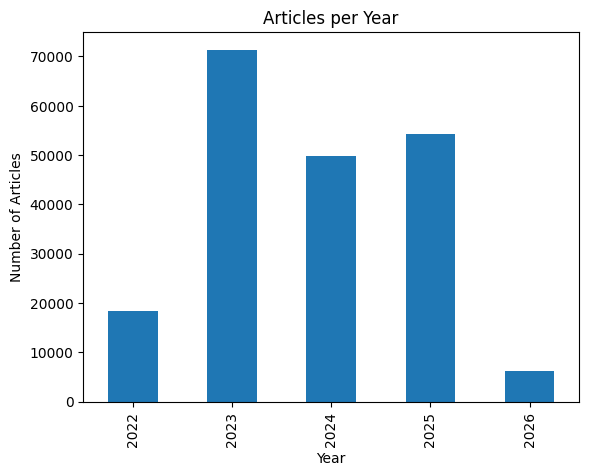

In [ ]:
df['date'].dt.year.value_counts().sort_index().plot(kind='bar')

plt.xlabel("Year")
plt.ylabel("Number of Articles")
plt.title("Articles per Year")
plt.show()

## 11. Source Distribution

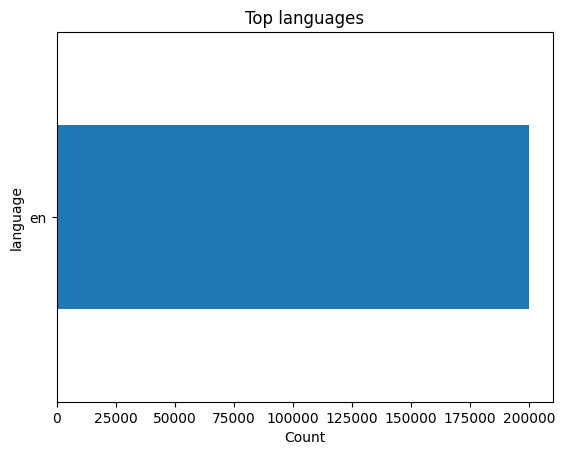

In [ ]:
df['language'].value_counts().head(20)

df['language'].value_counts().head(15).plot(kind='barh')

plt.xlabel("Count")
plt.ylabel("language")
plt.title("Top languages")
plt.show()

## 12. Inspect Noise in Data

## 13. Basic Text Statistics

## 15. Identify Useful Fields

In [ ]:
(df.notnull().mean()*100).sort_values(ascending=False)

,0
url,100.0
date,100.0
language,100.0
title,100.0
text,100.0
char_count,100.0
word_count,100.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 199989 entries, 0 to 199988
Data columns (total 7 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   url         199989 non-null  object        
 1   date        199989 non-null  datetime64[ns]
 2   language    199989 non-null  object        
 3   title       199989 non-null  object        
 4   text        199989 non-null  object        
 5   char_count  199989 non-null  int64         
 6   word_count  199989 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(4)
memory usage: 10.7+ MB


## 16. Save Exploration Artifacts (Important for later notebooks)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df.to_parquet("/content/drive/MyDrive/NLP Final Project/raw_news_data.parquet", index=False)

In [ ]:
test

**Reasoning**:
The previous code failed because `nltk.word_tokenize` specifically required the `punkt_tab` resource, which was not explicitly downloaded. I will add `nltk.download('punkt_tab', quiet=True)` to ensure all necessary NLTK data for tokenization is available.



**Reasoning**:
With the N-grams generated, the next logical step is to collect all the unigrams, bigrams, and trigrams into separate lists to prepare them for frequency analysis. This will allow for easy counting and identification of the most common N-grams.



# Task
Install `tqdm` if needed, then generate `cleaned_title`, `unigrams`, `bigrams`, and `trigrams` for the 'title' column of the DataFrame using `preprocess_text` and `generate_ngrams` functions with progress bars. Finally, print the counts of unigrams, bigrams, and trigrams to verify their successful generation.